In [90]:
import plotly.io as pio
pio.renderers.default = "browser"
print("Plotly renderer set to 'browser' — fig.show() abrirá el navegador externo.")

Plotly renderer set to 'browser' — fig.show() abrirá el navegador externo.


# Summer School UPC
## Febrero 2026

# Análisis Inteligente de Datos


## Docente: PhD. Débora Chan


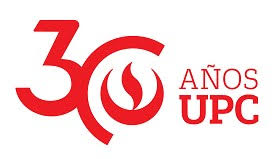

# <font color="darkgreen">La biblioteca Pandas </font>

La biblioteca pandas de Python es muy utilizada para la ciencia de datos, el análisis y el machine learning, que ofrece una forma flexible e intuitiva de manejar conjuntos de datos de todos los tamaños. Una de las funcionalidades más importantes de pandas son las herramientas que proporciona para leer y escribir datos. 

El  DataFrame que es la estructura fundamental de Pandas, estos son estructuras de datos etiquetados bidimensionales con columnas de tipos potencialmente diferentes. Los Pandas DataFrame constan de tres componentes principales: los datos, el índice y las columnas.

Adicionalmente, con la estructura Pandas DataFrame puedes especificar los nombres de índice y columna. El índice indica la diferencia en las filas, mientras que los nombres de las columnas indican la diferencia en las columnas. Estos componentes son muy útiles cuando se requiera manipular los datos.

Pero con Pandas no solamente puedes manipular los datos, también puedes limpiarlos, transformarlos y analizarlos.

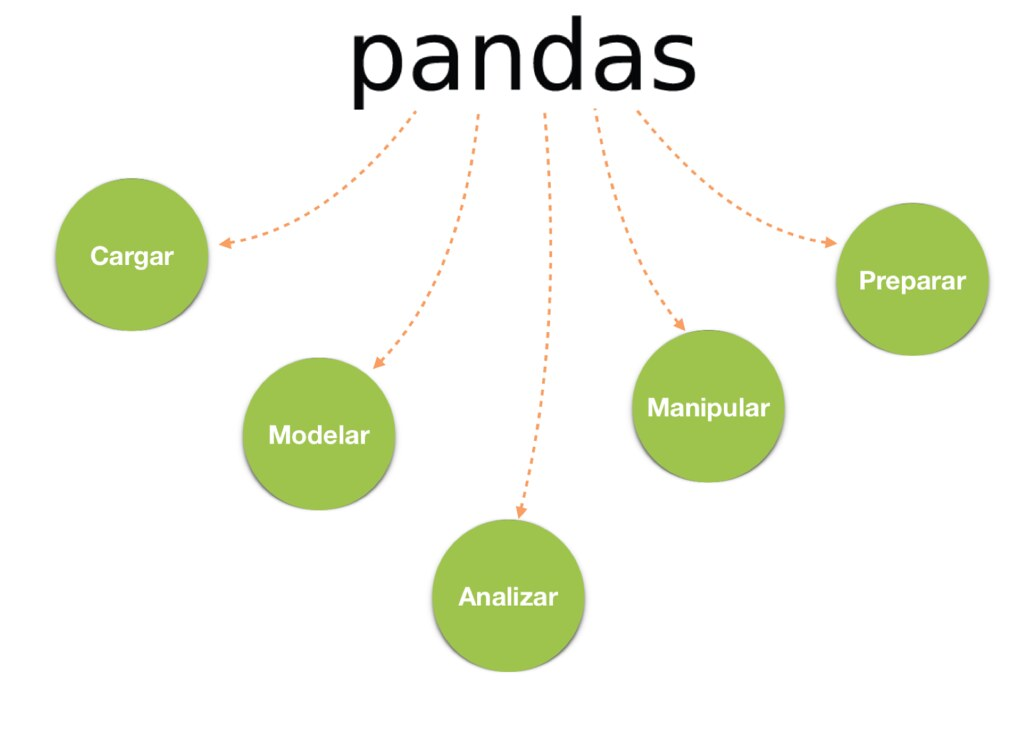

Pandas dispone de tres estructuras de datos diferentes:

***Series***: Estructura de una dimensión.

***DataFrame***: Estructura de dos dimensiones (tablas).

***Panel***: Estructura de tres dimensiones (cubos)

In [10]:
#!pip install pandas # instalación de la biblioteca

import pandas as pd
import numpy as np

## <font color="violet">Las Series</font>

Las Series de Pandas son una estructura de datos unidimensional que puede almacenar valores y para cada valor también tiene un índice único. Es esencialmente una columna. 

A continuación un ejemplo para crear una serie en pandas:

In [11]:
capitales = pd.Series({"Argentina":"Buenos Aires", "Chile":"Santiago de Chile", "Colombia":"Bogotá", "Perú":"Lima"})
print('capitales:')
print(capitales)

capitales:
Argentina         Buenos Aires
Chile        Santiago de Chile
Colombia                Bogotá
Perú                      Lima
dtype: str


## <font color="violet">Los Data Frames</font>

In [12]:
df = pd.DataFrame(np.array([[1, 2, 3], [4, 5, 6]]))
print('DataFrame:')
print(df)

DataFrame:
   0  1  2
0  1  2  3
1  4  5  6


Generalmente para obtener los datos de Machine Learning lo vas a hacer de alguna de las siguientes formas:

Abrir un archivo local, generalmente un archivo CSV, pero también podría ser un archivo de texto delimitado, excel, entre otros.
Abrir un archivo o base de datos de manera remota desde un sitio web a través de una URL.
Para cumplir con estas acciones hay diferentes comandos para cada una de ellas

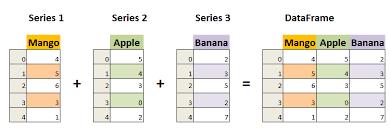

In [13]:
semillas = pd.read_csv('C:\\Users\\nanab\\Downloads\\OneDrive_1_2-9-2026\\datos\\semillas.csv',sep=";")
semillas =pd.DataFrame(semillas)
semillas.head()

,parcela,germ,humedad,cobertura
0,1,22.0,1,no
1,2,41.0,3,no
2,3,66.0,5,no
3,4,82.0,7,no
4,5,79.0,9,no


## <font color="darkred">Manipulación de un DataFrame</font>


Una vez que tienes un DataFrame, puedes empezar a manipularlo y analizarlo. Pandas tiene muchas funciones útiles para hacerlo, alguna de las mas comunes:

In [14]:
semillas.shape # nos da las dimensiones de la base

(48, 4)

In [15]:
semillas.axes #nos indica la cantidad de datos y los nombres de las columnas

[RangeIndex(start=0, stop=48, step=1),
 Index(['parcela', 'germ', 'humedad', 'cobertura'], dtype='str')]

In [16]:
semillas.index #nos indica la cantidad de índices de los datos

RangeIndex(start=0, stop=48, step=1)

In [17]:
semillas.columns #nos indica los nombres de las variables del dataframe

Index(['parcela', 'germ', 'humedad', 'cobertura'], dtype='str')

### <font color="darkgreen">Seleccionar columnas</font>


Para seleccionar una columna específica del DataFrame, puedes utilizar el nombre de la columna dentro de corchetes y como argumento del DataFrame.

In [18]:
print(semillas['cobertura'].head())

0    no
1    no
2    no
3    no
4    no
Name: cobertura, dtype: str


### <font color="darkgreen">Seleccionar filas</font>


Para seleccionar filas específicas del DataFrame, puedes utilizar la función iloc, que indexa el DataFrame por posición. 

In [19]:
print(semillas.iloc[0]) # muestra la primera fila del dataframe

parcela         1
germ         22.0
humedad         1
cobertura      no
Name: 0, dtype: object


In [20]:
print(semillas.iloc[0:5]) # muestra las primeras 5 filas del dataframe

   parcela  germ  humedad cobertura
0        1  22.0        1        no
1        2  41.0        3        no
2        3  66.0        5        no
3        4  82.0        7        no
4        5  79.0        9        no


### <font color="darkgreen">Cambiar el nombre de una columna</font>



Para cambiar el nombre a una columna puedes usar este código. Tienes dos formas diferentes de hacerlo con el parametro <font color="magenta">inplace</font> o sin el.

In [21]:
# Cambiar el nombre y reasignar el dataframe

semillas.rename({'humedad': 'Humedad'}, axis=1, inplace=True)

print(semillas.tail())

    parcela  germ  Humedad cobertura
43       44  77.0        3       yes
44       45  76.0        5       yes
45       46  62.0        7       yes
46       47   NaN        9       yes
47       48   0.0       11       yes



### <font color="darkgreen">Filtrar filas</font>

Podemos tambien filtrar filas en función de un criterio específico, puedes utilizar la función loc. Por ejemplo, para seleccionar todas las filas donde la humedad es mayor que 10:

In [22]:
print(semillas.loc[semillas['Humedad'] > 10])

    parcela  germ  Humedad cobertura
5         6   0.0       11        no
11       12   0.0       11        no
17       18   0.0       11        no
23       24   0.0       11        no
29       30   0.0       11       yes
35       36   0.0       11       yes
41       42   0.0       11       yes
47       48   0.0       11       yes


In [23]:
print(semillas.loc[((semillas['germ'] > 10) & (semillas['germ'] < 49)) | (semillas['germ'] == 59)].sort_values(by='germ', ascending=False))

    parcela  germ  Humedad cobertura
13       14  59.0        3        no
7         8  46.0        3        no
40       41  45.0        9       yes
24       25  45.0        1       yes
42       43  43.0        1       yes
36       37  42.0        1       yes
1         2  41.0        3        no
30       31  41.0        1       yes
39       40  40.0        7       yes
19       20  38.0        3        no
34       35  36.0        9       yes
28       29  31.0        9       yes
12       13  27.0        1        no
6         7  25.0        1        no
18       19  23.0        1        no
0         1  22.0        1        no


# Ejercicio 19

a) Leer la base de datos futbol.xlsx (futbol = pd.read_excel('.../futbol.xlsx'))

b) Convertirla en DataFrame

c) Visualizar las primeras líneas

d) Inspeccionar el nombre de las variables

e) Inspeccionar la cantidad de registros

f) Seleccionar los registros donde los partidos jugados superen los 40.

g) Renombrar la columna Puntos con Puntaje

In [24]:
# a) b) y c)

futbol = pd.read_excel('C:\\Users\\nanab\\Downloads\\OneDrive_1_2-9-2026\\datos\\futbol.xlsx')
futbol =pd.DataFrame(futbol)
futbol.head()

,País,Mundiales,Puntos,PJ,PG,PE,PP,Rendimiento,GF,GC,Campeón
0,Brasil,20,227,104,70,17,17,0.73,221,102,1
1,Alemania,18,218,106,66,20,20,0.69,224,121,1
2,Italia,18,156,83,45,21,17,0.63,128,77,1
3,Argentina,16,140,77,42,14,21,0.61,131,84,1
4,España,14,99,59,29,12,18,0.56,92,66,1


In [25]:
# d)
futbol.columns

Index(['País', 'Mundiales', 'Puntos', 'PJ', 'PG', 'PE', 'PP', 'Rendimiento',
       'GF', 'GC', 'Campeón'],
      dtype='str')

In [26]:
# e)
futbol.index

RangeIndex(start=0, stop=77, step=1)

In [27]:
# f)
print(futbol.loc[futbol['PJ'] > 40])

            País  Mundiales  Puntos   PJ  PG  PE  PP  Rendimiento   GF   GC  \
0         Brasil         20     227  104  70  17  17         0.73  221  102   
1       Alemania         18     218  106  66  20  20         0.69  224  121   
2         Italia         18     156   83  45  21  17         0.63  128   77   
3      Argentina         16     140   77  42  14  21         0.61  131   84   
4         España         14      99   59  29  12  18         0.56   92   66   
5     Inglaterra         14      98   62  26  20  16         0.53   79   56   
6        Francia         14      96   59  28  12  19         0.54  106   71   
7   Países Bajos         10      93   50  27  12  11         0.62   86   48   
8        Uruguay         12      72   51  20  12  19         0.47   80   71   
9         Suecia         11      61   46  16  13  17         0.44   74   69   
11        Serbia         11      59   43  17   8  18         0.46   64   58   
12        México         15      56   53  14  14  25

In [28]:
# g)
futbol.rename({'Puntos': 'Puntaje'}, axis=1,inplace=True)
print(futbol.tail)

<bound method NDFrame.tail of                       País  Mundiales  Puntaje   PJ  PG  PE  PP  Rendimiento  \
0                   Brasil         20      227  104  70  17  17         0.73   
1                 Alemania         18      218  106  66  20  20         0.69   
2                   Italia         18      156   83  45  21  17         0.63   
3                Argentina         16      140   77  42  14  21         0.61   
4                   España         14       99   59  29  12  18         0.56   
..                     ...        ...      ...  ...  ..  ..  ..          ...   
72  Emiratos Árabes Unidos          1        0    3   0   0   3         0.00   
73                   China          1        0    3   0   0   3         0.00   
74                   Haití          1        0    3   0   0   3         0.00   
75     República del Congo          1        0    3   0   0   3         0.00   
76             El Salvador          2        0    6   0   0   6         0.00   

     GF  

### <font color="darkgreen">Agrupar y resumir datos</font>

Pandas permite agrupar y resumir los datos de un DataFrame en función de una o varias columnas. Ejemplo, para agrupar el DataFrame por la columna "ciudad" y obtener la media de la edad para cada ciudad, podemos hacer lo siguiente:

In [29]:
print(semillas.groupby('cobertura')['germ'].mean())

cobertura
no     47.958333
yes    47.652174
Name: germ, dtype: float64


In [30]:
print(semillas.groupby('Humedad')['germ'].median())

Humedad
1     34.0
3     62.0
5     73.5
7     67.5
9     68.0
11     0.0
Name: germ, dtype: float64


### <font color="darkgreen">Exportar un archivo</font>

In [31]:
semillas.to_csv('C:\\Users\\nanab\\Downloads\\OneDrive_1_2-9-2026\\datos\\semi.csv', index=False)

### <font color="darkgreen">Acceso a los elementos de un DataFrame</font>



In [32]:
semillas.iloc[1, 2] # Devuelve el elemento que se encuentra en la fila 2 y la columna 3 del DataFrame



np.int64(3)

In [33]:
semillas.iloc[1:3, 1:4] # Devuelve los elementos de las filas 1 y 2 y columnas 2, 3 y 4.



,germ,Humedad,cobertura
1,41.0,3,no
2,66.0,5,no


In [34]:
semillas.iloc[2] # Devuelve una serie con los elementos de la fila 3 del DataFrame.

parcela         3
germ         66.0
Humedad         5
cobertura      no
Name: 2, dtype: object

# Ejercicio 20

a) De la base de futbol seleccionar las primeras dos filas y las columnas 2 hasta 5.

b) De la base de futbol seleccionar la tercera fila

c) Leer el elemento de la base de futbol que esta en la cuarta columna y en la fila 7.

d) Seleccionar las primeras dos filas y las primeras dos columnas, 
guardarlos en una base denomidad fulbito y exportarla en un csv.


In [35]:
# a) Seleccionar las primeras dos filas y las columnas 2 hasta 5
print("a) Primeras dos filas y columnas 2 hasta 5:")
print(futbol.iloc[0:2, 1:5])
print()

# b) Seleccionar la tercera fila
print("b) Tercera fila:")
print(futbol.iloc[2])
print()

# c) Elemento de la cuarta columna y fila 7
print("c) Elemento en la columna 4 y fila 7:")
print(futbol.iloc[6, 3])
print()

# d) Seleccionar las primeras dos filas y las primeras dos columnas,
# guardarlos en una base denominada fulbito y exportarla en csv
fulbito = futbol.iloc[0:2, 0:2]

print("d) Base fulbito:")
print(fulbito)

fulbito.to_csv(
    r"C:\Users\nanab\Downloads\OneDrive_1_2-9-2026\datos\fulbito.csv",
    index=False
)

print("Archivo fulbito.csv exportado exitosamente")


a) Primeras dos filas y columnas 2 hasta 5:
   Mundiales  Puntaje   PJ  PG
0         20      227  104  70
1         18      218  106  66

b) Tercera fila:
País           Italia
Mundiales          18
Puntaje           156
PJ                 83
PG                 45
PE                 21
PP                 17
Rendimiento      0.63
GF                128
GC                 77
Campeón             1
Name: 2, dtype: object

c) Elemento en la columna 4 y fila 7:
59

d) Base fulbito:
       País  Mundiales
0    Brasil         20
1  Alemania         18
Archivo fulbito.csv exportado exitosamente


### <font color="darkgreen">Añadir columnas a un DataFrame</font>


In [36]:
semillas['tipo'] = pd.Series(["Criollas","Mejoradas","Hibridas","Mejoradas","Hibridas","Criollas",
                              "Criollas","Mejoradas","Hibridas","Hibridas","Mejoradas","Criollas","Mejoradas","Hibridas","Mejoradas","Mejoradas","Criollas",
                              "Mejoradas","Mejoradas","Hibridas","Criollas","Mejoradas","Hibridas",
                              "Criollas","Mejoradas","Hibridas","Mejoradas","Mejoradas","Criollas",
                              "Mejoradas","Hibridas","Mejoradas","Criollas","Mejoradas","Criollas",
                              "Mejoradas", "Criollas","Mejoradas","Hibridas","Hibridas",
                              "Mejoradas","Hibridas","Mejoradas","Mejoradas","Criollas","Hibridas"])
semillas

,parcela,germ,Humedad,cobertura,tipo
0,1,22.0,1,no,Criollas
1,2,41.0,3,no,Mejoradas
2,3,66.0,5,no,Hibridas
3,4,82.0,7,no,Mejoradas
4,5,79.0,9,no,Hibridas
5,6,0.0,11,no,Criollas
6,7,25.0,1,no,Criollas
7,8,46.0,3,no,Mejoradas
8,9,72.0,5,no,Hibridas
9,10,73.0,7,no,Hibridas


### <font color="darkgreen">Operaciones sobre una columna de un DF </font>

In [37]:
from math import log  # importamos la función log de la biblioteca math

print(semillas['Humedad'].apply(log).head())# aplicamos esa función a la columna humedad

0    0.000000
1    1.098612
2    1.609438
3    1.945910
4    2.197225
Name: Humedad, dtype: float64


### <font color="darkgreen">Eliminar columnas de un DataFrame </font>


del d['nombre'] # Elimina la columna que se llama 'nombre' del DataFrame.

df.pop(nombre) # Elimina la columna que se llama 'nombre' del DataFrame y la devuelve como una serie.

In [38]:
df = pd.read_excel(r'C:\Users\nanab\Downloads\OneDrive_1_2-9-2026\datos\colesterol.xlsx')

print(df) # es el archivo de colesterol pero como vamos a eliminar cosas lo llamamos con otro nombre
                          



                             nombre  edad sexo   peso  altura  colesterol
0      José Luis Martínez Izquierdo    18    H   85.0    1.79       182.0
1                    Rosa Díaz Díaz    32    M   65.0    1.73       232.0
2             Javier García Sánchez    24    H    NaN    1.81       191.0
3               Carmen López Pinzón    35    M   65.0    1.70       200.0
4              Marisa López Collado    46    M   51.0    1.58       148.0
5                 Antonio Ruiz Cruz    68    H   66.0    1.74       249.0
6           Antonio Fernández Ocaña    51    H   62.0    1.72       276.0
7             Pilar Martín González    22    M   60.0    1.66         NaN
8              Pedro Gálvez Tenorio    35    H   90.0    1.94       241.0
9           Santiago Reillo Manzano    46    H   75.0    1.85       280.0
10            Macarena Álvarez Luna    53    M   55.0    1.62       262.0
11       José María de la Guía Sanz    58    H   78.0    1.87       198.0
12  Miguel Angel Cuadrado Gutiérrez   

In [39]:
# Sacar la columna 'edad' del DataFrame y asignarla a una variable llamada 'edad'
edad = df.pop('edad')


In [40]:
print(df) # inspeccionamos la base original y verificamos que ya no tiene a la variable edad

                             nombre sexo   peso  altura  colesterol
0      José Luis Martínez Izquierdo    H   85.0    1.79       182.0
1                    Rosa Díaz Díaz    M   65.0    1.73       232.0
2             Javier García Sánchez    H    NaN    1.81       191.0
3               Carmen López Pinzón    M   65.0    1.70       200.0
4              Marisa López Collado    M   51.0    1.58       148.0
5                 Antonio Ruiz Cruz    H   66.0    1.74       249.0
6           Antonio Fernández Ocaña    H   62.0    1.72       276.0
7             Pilar Martín González    M   60.0    1.66         NaN
8              Pedro Gálvez Tenorio    H   90.0    1.94       241.0
9           Santiago Reillo Manzano    H   75.0    1.85       280.0
10            Macarena Álvarez Luna    M   55.0    1.62       262.0
11       José María de la Guía Sanz    H   78.0    1.87       198.0
12  Miguel Angel Cuadrado Gutiérrez    H  109.0    1.98       210.0
13            Carolina Rubio Moreno    M   61.0 

In [41]:
print(edad) # verificamos que la variable edad si guardó los datos

0     18
1     32
2     24
3     35
4     46
5     68
6     51
7     22
8     35
9     46
10    53
11    58
12    27
13    20
Name: edad, dtype: int64


### <font color="darkgreen">Añadir una fila a un DataFrame </font>


In [42]:
import pandas as pd

# Crear un DataFrame de ejemplo
data1 = pd.DataFrame({
    'edad': [30, 35, 40],
    'nombre': ['Juan', 'Ana', 'Pedro'],
    'altura': [1.75, 1.60, 1.80],
    'profesion': ['Ingeniero', 'Doctor', 'Abogado'],
    'ciudad': ['Buenos Aires', 'Madrid', 'Lima']
})



# Imprimir el DataFrame para verlo
print(data1)




   edad nombre  altura  profesion        ciudad
0    30   Juan    1.75  Ingeniero  Buenos Aires
1    35    Ana    1.60     Doctor        Madrid
2    40  Pedro    1.80    Abogado          Lima


In [43]:
# Crear una nueva fila como una Serie
row1 = pd.Series([25, 'Franco', 1.9, 'Licenciado', 'Paris'], index=data1.columns)

# Agregar la nueva fila al final del DataFrame
data1.loc[len(data1)] = row1

# Imprimir el DataFrame para verificar que se haya agregado correctamente la nueva fila
print(data1)

   edad  nombre  altura   profesion        ciudad
0    30    Juan    1.75   Ingeniero  Buenos Aires
1    35     Ana    1.60      Doctor        Madrid
2    40   Pedro    1.80     Abogado          Lima
3    25  Franco    1.90  Licenciado         Paris


# Ejercicio 21

a) En la base de futbol eliminar la columna de PJ y guardarla en una serie. Mostrar la base y la serie actualizadas.

b) Agregar una columna en la base de futbol con el continente de cada pais.

c) Agregar una fila con datos de fantasía.

d) Eliminar la tercera fila de la base de futbol.

In [44]:
# b) Agregar una columna con el continente de cada país
continentes = {
    'Brasil': 'América', 'Alemania': 'Europa', 'Italia': 'Europa', 'Argentina': 'América', 'España': 'Europa',
    'Francia': 'Europa', 'Inglaterra': 'Europa', 'Uruguay': 'América', 'Suecia': 'Europa', 'Bélgica': 'Europa',
    'Países Bajos': 'Europa', 'Hungría': 'Europa', 'Portugal': 'Europa', 'Yugoslavia': 'Europa', 'Czechia': 'Europa',
    'Rusia': 'Europa', 'México': 'América', 'Polonia': 'Europa', 'Chile': 'América', 'Serbia': 'Europa',
    'Gales': 'Europa', 'Croacia': 'Europa', 'Suiza': 'Europa', 'Dinamarca': 'Europa', 'EEUU': 'América',
    'Austria': 'Europa', 'Paraguay': 'América', 'Escocia': 'Europa', 'Rumania': 'Europa', 'Bulgaria': 'Europa',
    'Colombia': 'América', 'Perú': 'América', 'Cuba': 'América', 'Senegal': 'África', 'Camerún': 'África',
    'Nigeria': 'África', 'Ghana': 'África', 'Argelia': 'África', 'Marruecos': 'África', 'Túnez': 'África',
    'Egipto': 'África', 'Sudáfrica': 'África', 'Irán': 'Asia', 'Japón': 'Asia', 'Corea del Sur': 'Asia',
    'Australia': 'Oceanía', 'Nueva Zelanda': 'Oceanía', 'Costa Rica': 'América', 'Honduras': 'América',
    'Panamá': 'América', 'Canadá': 'América', 'Jamaica': 'América', 'Trinidad y Tobago': 'América',
    'Arabia Saudita': 'Asia', 'Emiratos Árabes Unidos': 'Asia', 'China': 'Asia', 'Haití': 'América',
    'República del Congo': 'África', 'El Salvador': 'América'
}
futbol['Continente'] = futbol['País'].map(continentes)

# c) Agregar una fila con datos de fantasía
fila_fantasia = {
    'País': 'Atlántida', 'Mundiales': 0, 'Puntaje': 0, 'PG': 0, 'PE': 0, 'PP': 0,
    'Rendimiento': 0.0, 'GF': 0, 'GC': 0, 'Campeón': 0, 'Continente': 'Océano'
}
futbol.loc[len(futbol)] = fila_fantasia

# d) Eliminar la tercera fila de la base de futbol
futbol = futbol.drop(futbol.index[2])

print(futbol.head())

         País  Mundiales  Puntaje     PJ  PG  PE  PP  Rendimiento   GF   GC  \
0      Brasil         20      227  104.0  70  17  17         0.73  221  102   
1    Alemania         18      218  106.0  66  20  20         0.69  224  121   
3   Argentina         16      140   77.0  42  14  21         0.61  131   84   
4      España         14       99   59.0  29  12  18         0.56   92   66   
5  Inglaterra         14       98   62.0  26  20  16         0.53   79   56   

   Campeón Continente  
0        1    América  
1        1     Europa  
3        1    América  
4        1     Europa  
5        1     Europa  


In [45]:
#Verificar si hay datos nulos en el DataFrame
print('Datos nulos en el DataFrame:')
print(semillas.isnull())

Datos nulos en el DataFrame:
    parcela   germ  Humedad  cobertura   tipo
0     False  False    False      False  False
1     False  False    False      False  False
2     False  False    False      False  False
3     False  False    False      False  False
4     False  False    False      False  False
5     False  False    False      False  False
6     False  False    False      False  False
7     False  False    False      False  False
8     False  False    False      False  False
9     False  False    False      False  False
10    False  False    False      False  False
11    False  False    False      False  False
12    False  False    False      False  False
13    False  False    False      False  False
14    False  False    False      False  False
15    False  False    False      False  False
16    False  False    False      False  False
17    False  False    False      False  False
18    False  False    False      False  False
19    False  False    False      False  False
20   

In [46]:
#Suma de datos nulos en el DataFrame
print('Suma datos nulos en el DataFrame:')
print(semillas.isnull().sum())

Suma datos nulos en el DataFrame:
parcela      0
germ         1
Humedad      0
cobertura    0
tipo         2
dtype: int64


In [47]:
#Reemplaza los valores perdidos por la media
print('Reemplazar los valores perdidos por la media:')
print(semillas.germ.fillna(semillas.germ.mean ()))

Reemplazar los valores perdidos por la media:
0     22.000000
1     41.000000
2     66.000000
3     82.000000
4     79.000000
5      0.000000
6     25.000000
7     46.000000
8     72.000000
9     73.000000
10    68.000000
11     0.000000
12    27.000000
13    59.000000
14    51.000000
15    73.000000
16    74.000000
17     0.000000
18    23.000000
19    38.000000
20    78.000000
21    84.000000
22    70.000000
23     0.000000
24    45.000000
25    65.000000
26    81.000000
27    55.000000
28    31.000000
29     0.000000
30    41.000000
31    80.000000
32    73.000000
33    51.000000
34    36.000000
35     0.000000
36    42.000000
37    79.000000
38    74.000000
39    40.000000
40    45.000000
41     0.000000
42    43.000000
43    77.000000
44    76.000000
45    62.000000
46    47.808511
47     0.000000
Name: germ, dtype: float64


**También podemos importar un csv de un link**

In [48]:
colest = pd.read_csv(
'https://raw.githubusercontent.com/asalber/manual-python/master/datos/colesteroles.csv', sep=';', decimal=',')
print(colest.head())

                         nombre  edad sexo  peso  altura  colesterol
0  José Luis Martínez Izquierdo    18    H  85.0    1.79       182.0
1                Rosa Díaz Díaz    32    M  65.0    1.73       232.0
2         Javier García Sánchez    24    H   NaN    1.81       191.0
3           Carmen López Pinzón    35    M  65.0    1.70       200.0
4          Marisa López Collado    46    M  51.0    1.58       148.0


In [49]:
# Podemos pedir la información del objeto

colest.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   nombre      14 non-null     str    
 1   edad        14 non-null     int64  
 2   sexo        14 non-null     str    
 3   peso        13 non-null     float64
 4   altura      14 non-null     float64
 5   colesterol  13 non-null     float64
dtypes: float64(3), int64(1), str(2)
memory usage: 804.0 bytes


In [50]:
colest.size # nos indica el total de datos almacenados son 6 variables x 14 registros total 84


84

In [51]:
colest.columns # nos informa el nombre de las columnas del archivo



Index(['nombre', 'edad', 'sexo', 'peso', 'altura', 'colesterol'], dtype='str')

In [52]:
colest.index # nos dice cuantos registros tiene el data frame

RangeIndex(start=0, stop=14, step=1)

In [53]:
colest.dtypes # nos informa acerca del tipo de variable de cada columna

nombre            str
edad            int64
sexo              str
peso          float64
altura        float64
colesterol    float64
dtype: object

### <font color="darkgreen">Combinar varios DataFrames </font>


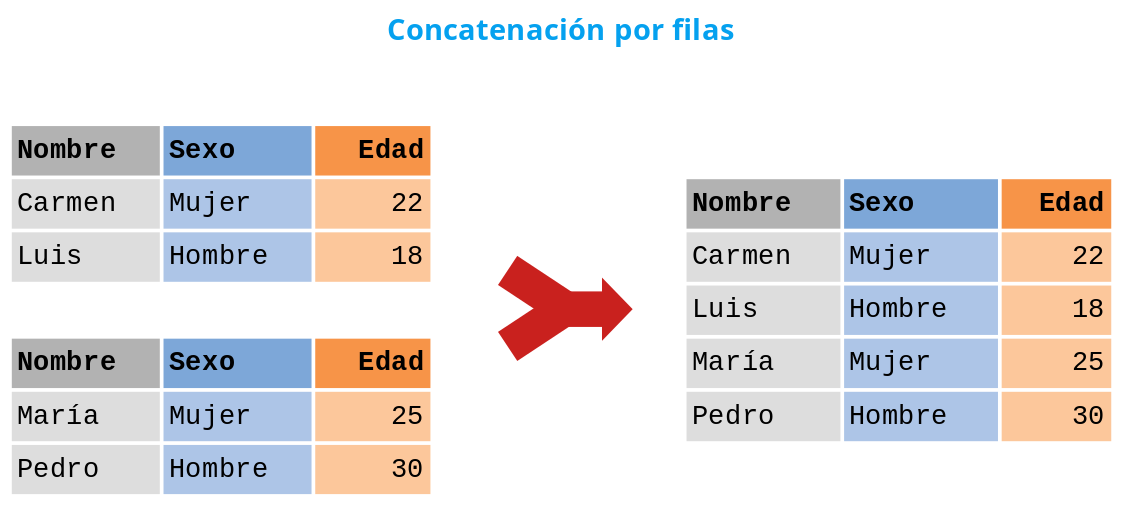

Las filas de los DataFrames se concatenan unas a continuación de las otras para formar el nuevo DataFrame. Para ello es necesario que los DataFrames que se combinen tengan el mismo índice de columnas.

In [54]:
df1 = pd.DataFrame({"Nombre":["Carmen", "Luis"], 
 "Sexo":["Mujer", "Hombre"], "Edad":[22, 18]}).set_index("Nombre")
print(df1)

          Sexo  Edad
Nombre              
Carmen   Mujer    22
Luis    Hombre    18


In [55]:
df2 = pd.DataFrame({"Nombre":["María", "Pedro"], 
"Sexo":["Mujer", "Hombre"], "Edad":[25, 30]}).set_index("Nombre")
print(df2)

          Sexo  Edad
Nombre              
María    Mujer    25
Pedro   Hombre    30


In [56]:
 df = pd.concat([df1, df2])
 df

,Sexo,Edad
Nombre,,
Carmen,Mujer,22
Luis,Hombre,18
María,Mujer,25
Pedro,Hombre,30


# **Ejercicio 22:**
* Armar una base con las notas de cuatro estudiantes del curso de Gestión y Estadística
* Armar otra base con las notas de los mismos alumnos en Data Science e Innovación
* Combinar ambas bases apoyándose en los nombres de los alumnos
* Armar una tercer base con otros cinco estudiantes y sus notas de Gesión y Estadística
* Combinar la primera y la tercera base.

In [57]:
import pandas as pd
notas1= pd.DataFrame({'Alumno': ['Leonel', 'Omar', 'Alejandra', 'Christian'],
                         'DS': [8,7,6,9],
                         'Innovacion': [4,7,8,6]})
    

notas2 = pd.DataFrame({'Alumno': ['Leonel', 'Omar', 'Alejandra', 'Christian'],
                         'Gestion': [9,9,8,6],
                          'Estadística': [6,7,8,9]})
    

    
notas3 = pd.DataFrame({'Alumno': ['Marcos', 'Tatiana', 'Alejo', 'Carla','Matias'],
                         'Gestion': [9,9,8,4,6],
                          'Estadística': [5,6,7,8,9]})
salida1 = pd.merge(notas1, notas2, on='Alumno')
print(salida1)

frames = [notas2, notas3]

salida2 = pd.concat(frames)
print(salida2)

      Alumno  DS  Innovacion  Gestion  Estadística
0     Leonel   8           4        9            6
1       Omar   7           7        9            7
2  Alejandra   6           8        8            8
3  Christian   9           6        6            9
      Alumno  Gestion  Estadística
0     Leonel        9            6
1       Omar        9            7
2  Alejandra        8            8
3  Christian        6            9
0     Marcos        9            5
1    Tatiana        9            6
2      Alejo        8            7
3      Carla        4            8
4     Matias        6            9


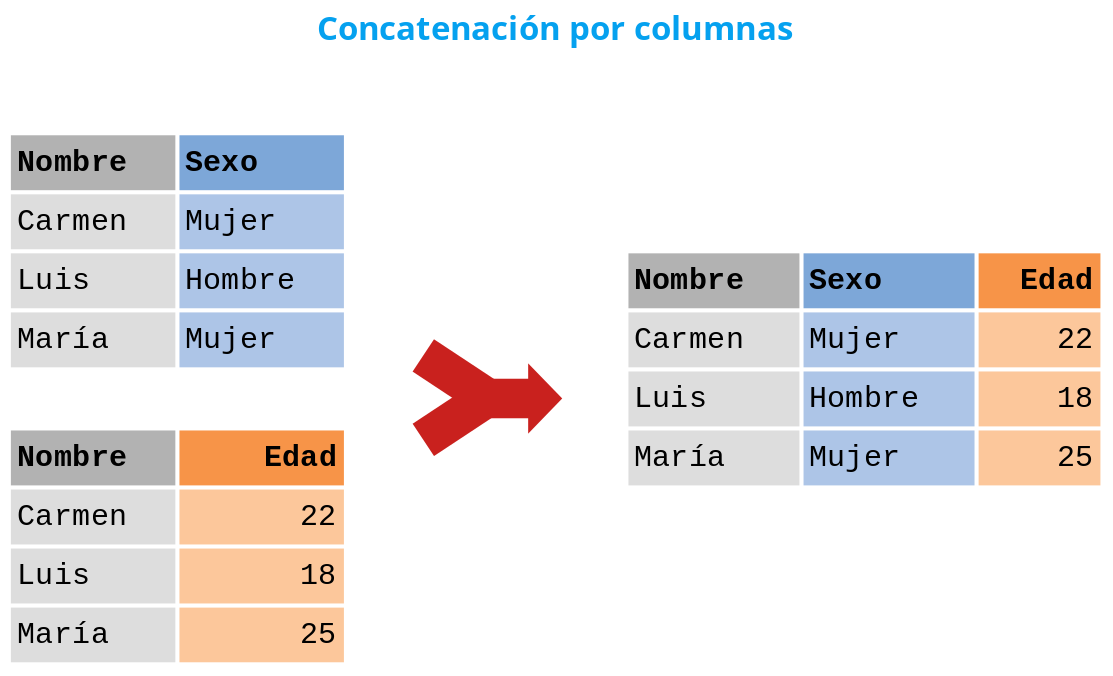

Las columnas de los DataFrames se concatenan unas a continuación de las otras para formar el nuevo DataFrame. Para ello es necesario que los DataFrames que se combinen tengan el mismo índice de filas.

In [58]:
df1 = pd.DataFrame({"Nombre":["Carmen", "Luis", "María"], 
"Sexo":["Mujer", "Hombre", "Mujer"]}).set_index("Nombre")
print(df1)

          Sexo
Nombre        
Carmen   Mujer
Luis    Hombre
María    Mujer


In [59]:
df2 = pd.DataFrame({"Nombre":["Carmen", "Luis", "María"], 
"Edad":[22, 18, 25]}).set_index("Nombre")
print(df2)

        Edad
Nombre      
Carmen    22
Luis      18
María     25


In [60]:
df = pd.concat([df1, df2], axis = 1)
print(df)

          Sexo  Edad
Nombre              
Carmen   Mujer    22
Luis    Hombre    18
María    Mujer    25


### <font color="darkgreen">Mezcla de DataFrames </font>



La mezcla de DataFrames permite integrar filas de dos DataFrames que contienen información en común en una o varias columnas o índices que se conocen como clave.

**"inner"**(por defecto)


El DataFrame resultante solo contiene las filas cuyos valores en la clave están en los dos DataFrames. Es equivalente a la intersección de conjuntos.

In [61]:
df1 = pd.DataFrame({"Nombre":["Carmen", "Luis", "María"],  "Sexo":["Mujer", "Hombre", "Mujer"]})

print(df1)

   Nombre    Sexo
0  Carmen   Mujer
1    Luis  Hombre
2   María   Mujer


In [62]:
df2 = pd.DataFrame({"Nombre":["María", "Pedro", "Luis"], "Edad":[25, 30, 18]})
print(df2)

  Nombre  Edad
0  María    25
1  Pedro    30
2   Luis    18


In [63]:
df = pd.merge(df1, df2, on="Nombre")
print(df)

  Nombre    Sexo  Edad
0   Luis  Hombre    18
1  María   Mujer    25


**"outer"** 

El DataFrame resultante contiene todas las filas de los dos DataFrames. Si una fila de un DataFrame no puede emparejarse con otra los mismos valores en la clave en el otro DataFrame, la fila se añade igualmente al DataFrame resultante rellenando las columnas del otro DataFrame con el valor NaN. Es equivalente a la unión de conjuntos.

In [64]:
df3 = pd.merge(df1, df2, on="Nombre", how="outer")
print(df3)

   Nombre    Sexo  Edad
0  Carmen   Mujer   NaN
1    Luis  Hombre  18.0
2   María   Mujer  25.0
3   Pedro     NaN  30.0


**"left"** 

El DataFrame resultante contiene todas las filas del primer DataFrame y descarta las filas del segundo DataFrame que no pueden emparejarse con alguna fila del primer DataFrame a través de la clave.

In [65]:
df4 = pd.merge(df1, df2, on="Nombre", how="left")
print(df4)

   Nombre    Sexo  Edad
0  Carmen   Mujer   NaN
1    Luis  Hombre  18.0
2   María   Mujer  25.0


**"right"** 

El DataFrame resultante contiene todas las filas del segundo DataFrame y descarta las filas del primero DataFrame que no pueden emparejarse con alguna fila del segundo DataFrame a través de la clave.

In [66]:
df5 = pd.merge(df1, df2, on="Nombre", how="right")
print(df5)

  Nombre    Sexo  Edad
0  María   Mujer    25
1  Pedro     NaN    30
2   Luis  Hombre    18


# **Ejercicio 23:**

Dadas las bases base1 y base2 combinarlas de distintas formas y explicar la diferencia entre los resultados obtenidos.




In [67]:
base1= pd.DataFrame({'Loc': ['Lanús', 'Tigre', 'Avellaneda', 'Quilmes'],
                         'gasto': [20,30,40,50],
                         'ingreso': [140,150,160,123]})
    

base2 = pd.DataFrame({'Loc': ['Lanús', 'Olivos', 'Avellaneda', 'Quilmes'],
                         'deuda_previa': [45,28,69,93],
                          'prestamo': [20,25,31,18]})

### <font color="darkgreen">Cambiar de formato largo a Ancho en  DataFrames </font>

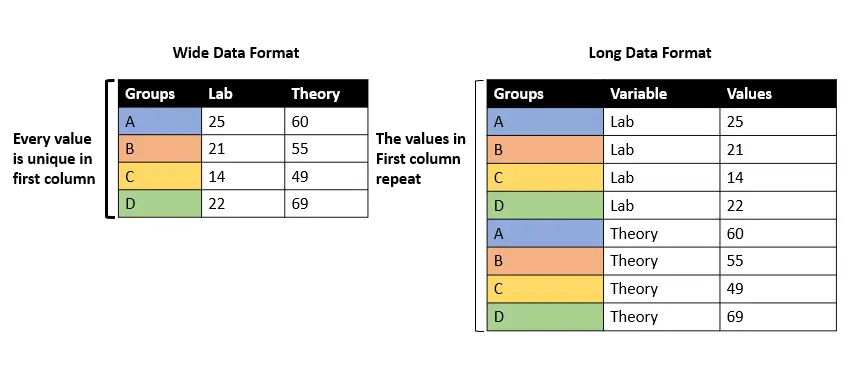

In [68]:
df = pd.DataFrame(
    {
        "Groups": ["A", "B", "C", "D"],
        "lab": [25, 21, 14, 22],
        "theory": [60, 55, 49, 69],
    }
)

print("Wide Data Frame:\n")
print(df)


Wide Data Frame:

  Groups  lab  theory
0      A   25      60
1      B   21      55
2      C   14      49
3      D   22      69


In [69]:
df = pd.melt(df, id_vars="Groups", value_vars=["lab", "theory"])

print("\n\nLong Data Frame:\n")
print(df)



Long Data Frame:

  Groups variable  value
0      A      lab     25
1      B      lab     21
2      C      lab     14
3      D      lab     22
4      A   theory     60
5      B   theory     55
6      C   theory     49
7      D   theory     69


### <font color="darkviolet">Camino de vuelta </font >

In [70]:
df = pd.DataFrame(
    {
        "Groups": ["A", "B", "C", "D"],
        "lab1": [25, 21, 14, 22],
        "lab2": [25, 21, 14, 22],
        "theory1": [60, 55, 49, 69],
        "theory2": [60, 55, 49, 69],
    }
)
df

,Groups,lab1,lab2,theory1,theory2
0,A,25,25,60,60
1,B,21,21,55,55
2,C,14,14,49,49
3,D,22,22,69,69


In [71]:
df = pd.wide_to_long(df, stubnames=["lab", "theory"], i="Groups", j="Exams")

print("\n\nLong Data Frame:\n")
print(df)



Long Data Frame:

              lab  theory
Groups Exams             
A      1       25      60
B      1       21      55
C      1       14      49
D      1       22      69
A      2       25      60
B      2       21      55
C      2       14      49
D      2       22      69


# <font color="darkmagenta">Graficos Estadísticos</font> 

Vamos a mejorar la interfaz gráfica. Usaremos otras bibliotecas.

## <font color="darkmagenta">Variables Categoricas</font> 

### **Diagrama Circular**

In [72]:
# importamos el archivo  y lo guardamos en la variable "paises".
paises = pd.read_excel('C:\\Users\\nanab\\Downloads\\OneDrive_1_2-9-2026\\datos\\paises.xlsx', header = 0)

paises


,Pais,Continente
0,Algeria,AFRICA
1,Angola,AFRICA
2,Benin,AFRICA
3,Botswana,AFRICA
4,Burkina,AFRICA
...,...,...
189,Paraguay,AMERICA
190,Peru,AMERICA
191,Surinam,AMERICA
192,Uruguay,AMERICA


            Pais
Continente      
AFRICA        54
AMERICA       35
ASIA          44
EUROPA        47
OCEANIA       14


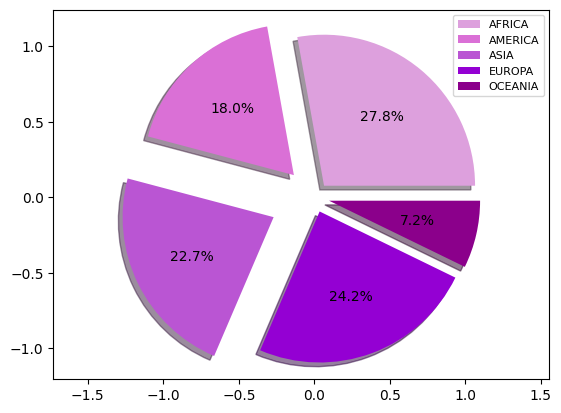

In [73]:

import pandas as pd
from matplotlib import pyplot as plt

cont_data=paises.groupby('Continente')[['Pais']].count()
print(cont_data)
color_list=['#DDA0DD','#DA70D6','#BA55D3','#9400D3','#8B008B']
explode = (0.1, 0.2, 0.3, 0.1,0.1)
fg, ax= plt.subplots()
ax.pie(cont_data['Pais'],autopct='%1.1f%%',colors=color_list,explode=explode,shadow=True,frame=True)
ax.legend(cont_data.index,loc='upper right',fontsize=8)
ax.axis('equal')
ax.set_facecolor("white")
plt.show()

**Se pueden separar algunas porciones de la torta**

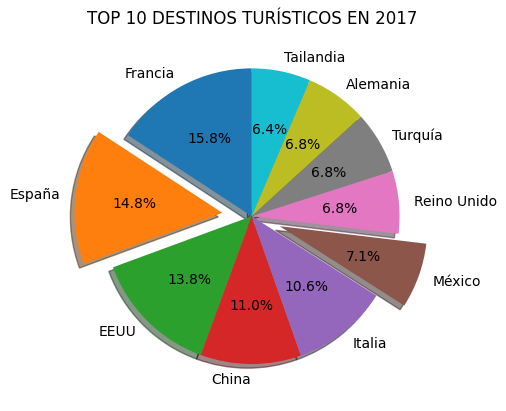

In [74]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.pyplot import pie

turistas = [86.9, 81.8, 75.9, 60.7, 58.2, 39.3, 37.7, 37.6, 37.5, 35.4]
paises_2 = ['Francia', 'España', 'EEUU', 'China', 'Italia',
          'México', 'Reino Unido', 'Turquía', 'Alemania', 'Tailandia']
explode = [0, 0.2, 0, 0, 0, 0.2, 0, 0, 0, 0]  # Destacar algunos

plt.pie(turistas, labels=paises_2, explode=explode,
        autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('TOP 10 DESTINOS TURÍSTICOS EN 2017')
plt.show()

### Gráfico de Barras

C:\Users\nanab\AppData\Local\Temp\ipykernel_1708\1299020371.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




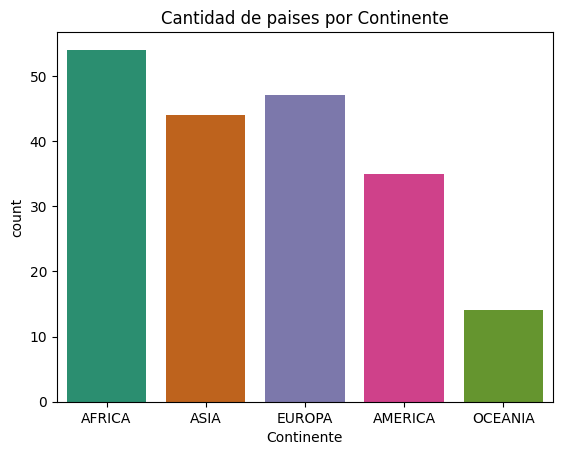

In [75]:
import seaborn as sns
# realizamos un gráfico de barras con seaborn con los datos de continente de la base paises

sns.countplot(x=paises['Continente'],palette="Dark2") # Dark2, Set1, Set2, Pastel1, Pastel2, Accent
plt.title("Cantidad de paises por Continente")
plt.show()

# **Ejercicio 24:**

* Importar la base razaperros guardarla en el objeto perros
* Seleccionar la variable funcion y realizar un gráfico de barras
* Con la variable inteligencia realizar un diagrama circular
* Realizar algún comentario de los gráficos

La base de datos **Titanic** contiene las siguientes variables:
    
   **Survived**: Indica si el pasajero sobrevivió (1) o no (0).
        
   **Pclass**: Clase del billete (1 = Primera clase, 2 = Segunda clase, 3 = Tercera clase).
        
   **Name**: Nombre del pasajero.
        
   **Sex**: Sexo del pasajero.
        
   **Age**: Edad del pasajero.
        
   **SibSp**: Número de hermanos/cónyuges a bordo.
        
   **Parch**: Número de padres/hijos a bordo.
        
   **Ticket**: Número del billete.
        
   **Fare**: Tarifa del pasajero.
        
   **Cabin**: Número de cabina del pasajero.
        
   **Embarked:** Puerto de embarque (C = Cherbourg, Q = Queenstown, S = Southampton).

In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# importando el conjunto de datos de Titanic
titanic= pd.read_excel('C:\\Users\\nanab\\Downloads\\OneDrive_1_2-9-2026\\datos\\titanic.xlsx' )
titanic.head(5)

,pclass,survived,name,sex,age,sibsp,parch,embarked
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,S
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,S
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,S
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,S
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,S


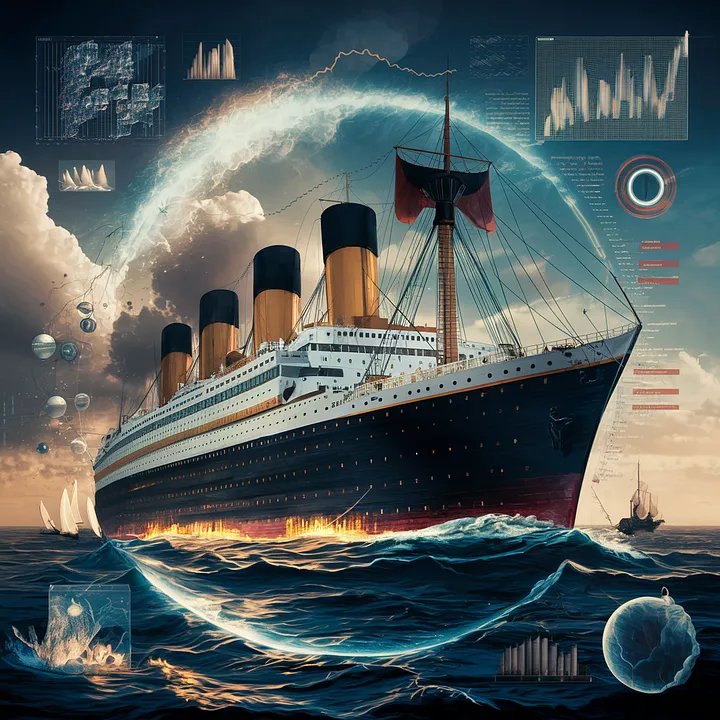

**Hacemos un diagrama de barras por supervivencia**

Text(0.5, 1.0, 'sobrevivieron -  total ')

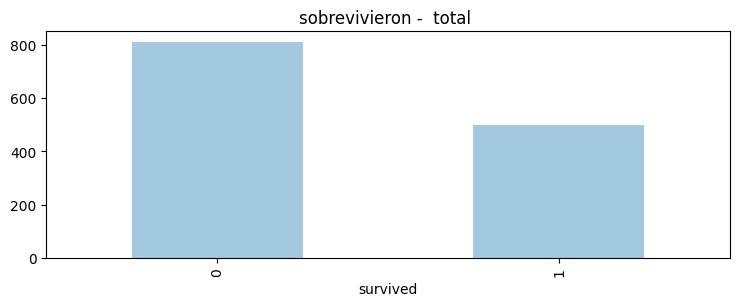

In [77]:
fig = plt.figure(figsize=(30,10)) #creamos un canva o figura de 30X10 pixeles
# Yo quiero ver un plot al costado del otro
plt.subplot2grid((3,3),(0,0))
titanic.survived.value_counts().plot(kind="bar", alpha=0.4)
plt.title("sobrevivieron -  total ")

**Realizar un conteo por sexo y puerto de embarque**

In [78]:
titanic.sex # para acceder a los datos de una columna
clasif1= titanic.groupby(["embarked", "sex"])["survived"].sum()
clasif1

embarked  sex   
C         female    102
          male       48
Q         female     37
          male        7
S         female    198
          male      106
Name: survived, dtype: int64

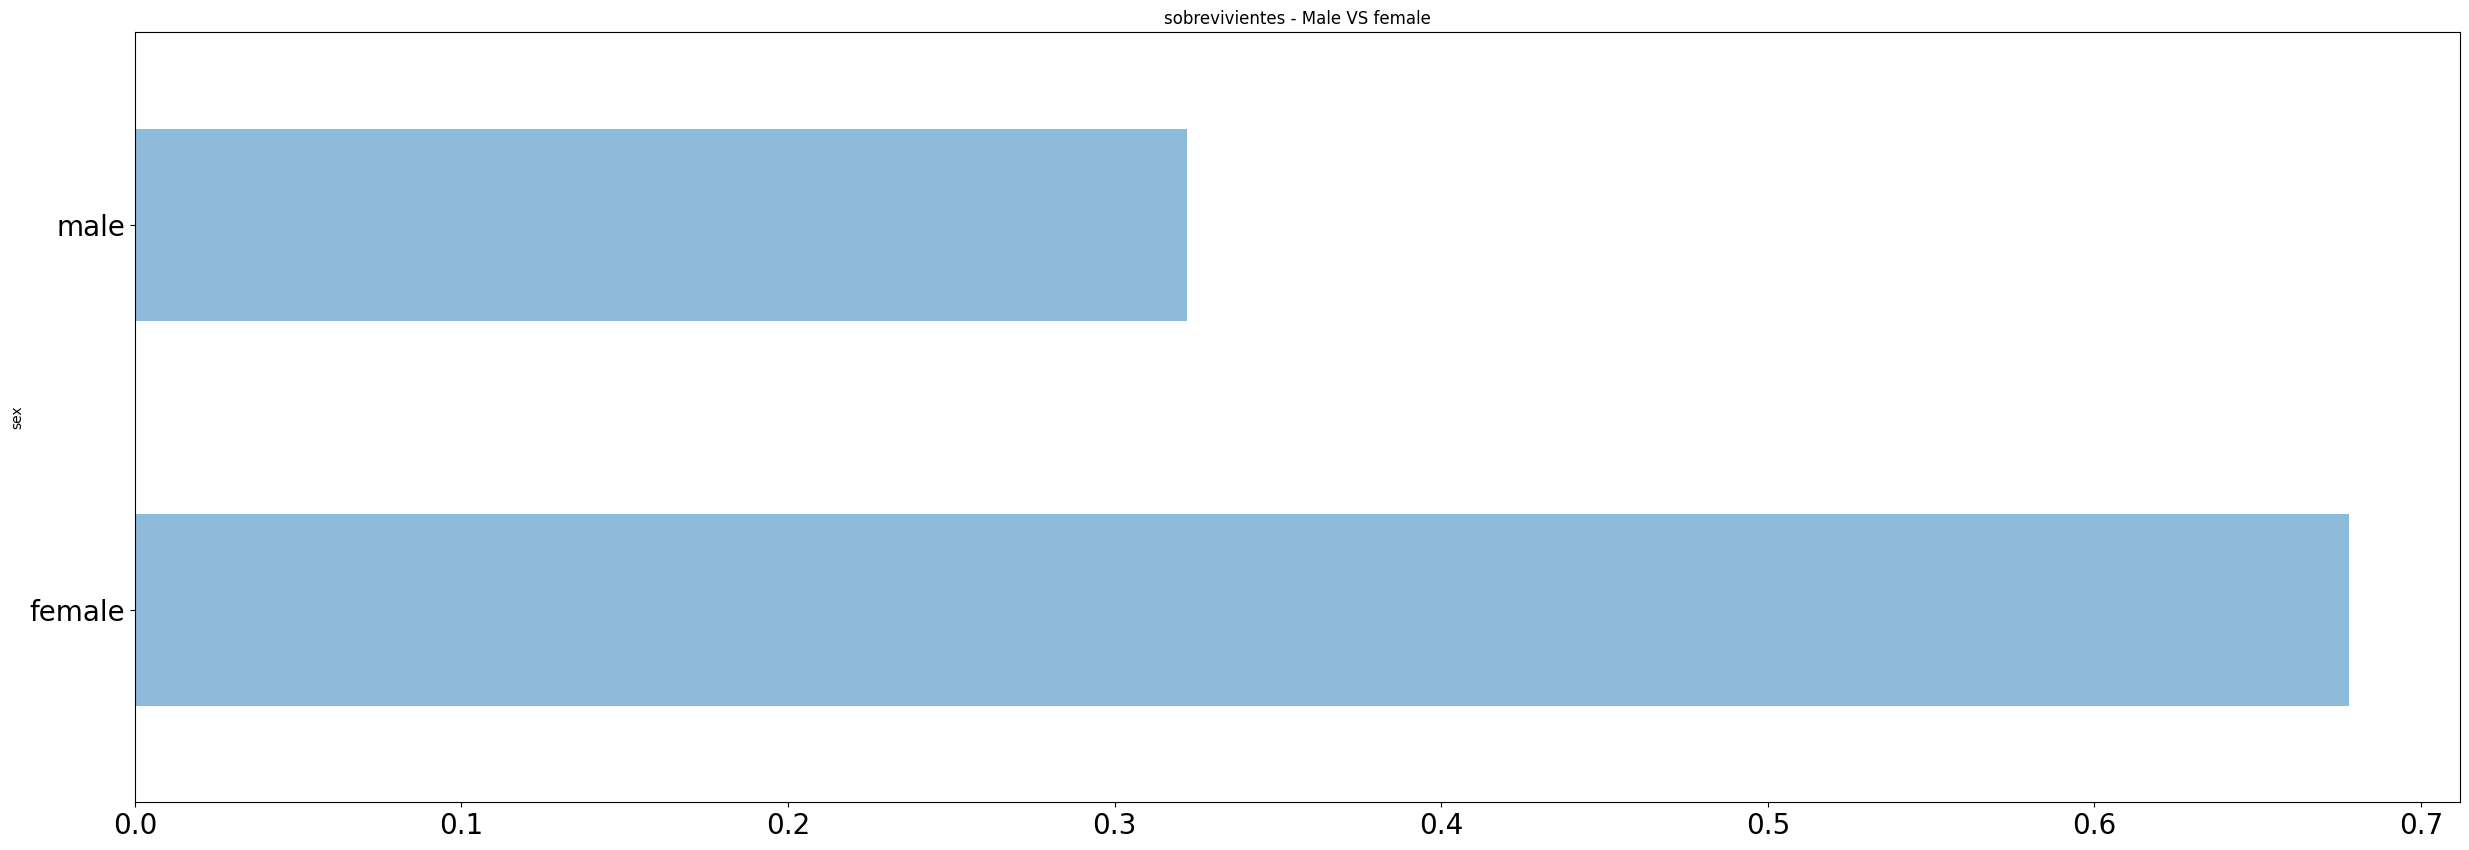

In [79]:
#podemos hacer barras horizontales
fig = plt.figure(figsize=(30,10))
titanic.sex[titanic.survived == 1].value_counts(normalize = True).plot(kind="barh", alpha=0.5)
# Ajustar el tamaño de la fuente en los ejes
plt.tick_params(axis='both', which='major', labelsize=20)
plt.title("sobrevivientes - Male VS female")
plt.show()

**Podemos hacer las barras horizontales**

**Barras Adyacentes**

In [80]:
titanic['survived']

0       1
1       1
2       0
3       0
4       0
       ..
1304    0
1305    0
1306    0
1307    0
1308    0
Name: survived, Length: 1309, dtype: int64

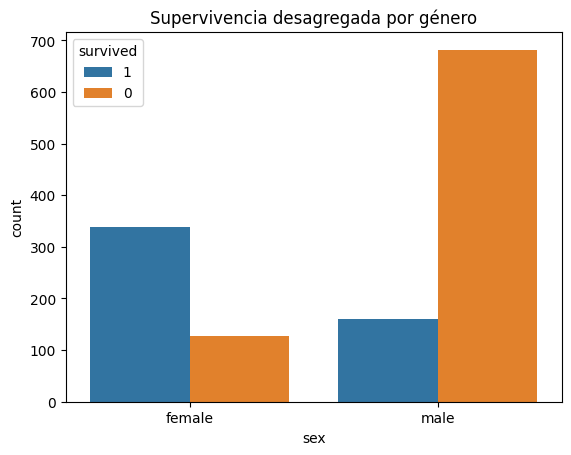

In [81]:
# Convertir los datos en la columna "survived" a cadenas de texto
titanic['survived'] = titanic['survived'].astype(str)

# Crear el gráfico de conteo utilizando seaborn
sns.countplot(x='sex', hue='survived', data=titanic)

plt.title('Supervivencia desagregada por género')
plt.show()

## <font color="darkmagenta">Gráfico de mosaicos</font> 

(<Figure size 640x480 with 3 Axes>,
 {('small', 'long'): (0.0,
   np.float64(0.0),
   0.49751243781094534,
   np.float64(0.6644518272425248)),
  ('small', 'short'): (0.0,
   np.float64(0.6677740863787375),
   0.49751243781094534,
   np.float64(0.33222591362126247)),
  ('large', 'long'): (0.5024875621890548,
   np.float64(0.0),
   0.49751243781094534,
   np.float64(0.3322259136212624)),
  ('large', 'short'): (0.5024875621890548,
   np.float64(0.33554817275747506),
   0.49751243781094534,
   np.float64(0.6644518272425249))})

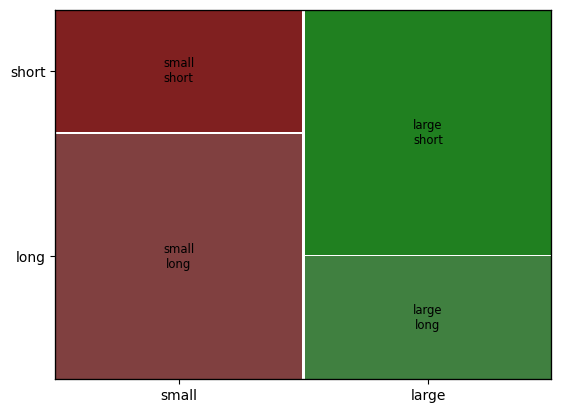

In [82]:
import statsmodels 
from statsmodels.graphics.mosaicplot import mosaic
myDataframe = pd.DataFrame({'size' : ['small', 'large', 'large', 'small', 'large', 'small'], 
                            'length' : ['long', 'short', 'short', 'long', 'long', 'short']})

mosaic(myDataframe, ['size', 'length']) # grafico de mosaicos a partir de una tabla de contingencia

**Hagamoslo para los datos de titanic**

(<Figure size 640x480 with 3 Axes>,
 {('1', 'female'): (0.0,
   np.float64(0.0),
   0.38007061712066104,
   np.float64(0.6757475083056478)),
  ('1', 'male'): (0.0,
   np.float64(0.6790697674418604),
   0.38007061712066104,
   np.float64(0.32093023255813946)),
  ('0', 'female'): (0.3850457414987705,
   np.float64(0.0),
   0.6149542585012295,
   np.float64(0.15646238948047092)),
  ('0', 'male'): (0.3850457414987705,
   np.float64(0.15978464861668354),
   0.6149542585012295,
   np.float64(0.8402153513833164))})

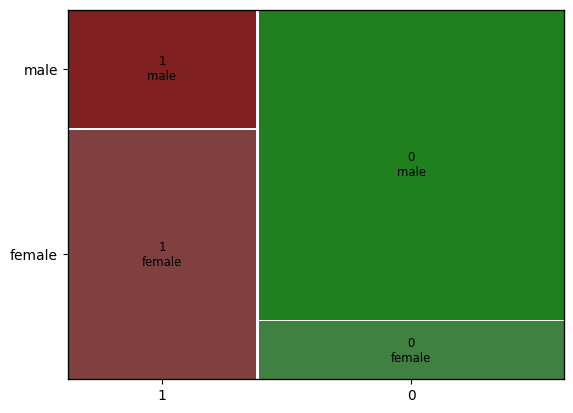

In [83]:
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.pyplot as plt
import seaborn as sns


mosaic(titanic, ['survived', 'sex'])



Datos tips: En este conjunto de datos hay información sobre propinas dejadas en un restaurante, con información sobre el día en el que se produjo, si fue en el almuerzo o la cena, el número de comensales, el sexo de la persona que dejó la propina, si era fumador o no.

  **total_bill**: El monto total de la factura, incluyendo el costo de la comida y las bebidas, en dólares.
    
   **tip**: La cantidad de propina dada por el cliente, en dólares.
    
   **sex**: El género del cliente (por ejemplo, 'Male' para hombre, 'Female' para mujer).
    
   **smoker**: Si el cliente fuma o no (por ejemplo, 'Yes' para sí, 'No' para no).
    
   **day**: El día de la semana en que se realizó la visita al restaurante (por ejemplo, 'Sun' para domingo, 'Sat' para sábado, etc.).
    
   **time**: Si la visita fue durante el almuerzo o la cena (por ejemplo, 'Lunch' para almuerzo, 'Dinner' para cena).
    
   **size**: El tamaño de la mesa (es decir, el número de personas en la mesa).

## <font color="darkmagenta">Boxplot</font> 

In [88]:
#!pip install plotly.express
import matplotlib.pyplot as plt
import plotly.express as px


df = px.data.tips()
fig = px.box(df, y="total_bill")
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

# <font color="red">Paseen con el cursor sobre el gráfico!! qué sucede???</font>

**Ahora veamos la posibilidad de comparar grupos**

In [91]:
# Cargar el conjunto de datos 'tips'
df = px.data.tips()

# Crear el gráfico de caja con facetas
fig = px.box(df, x="time", y="total_bill", title="Total by Time")

# Mostrar el gráfico
fig.show()

**Consideremos ahora dos factores**

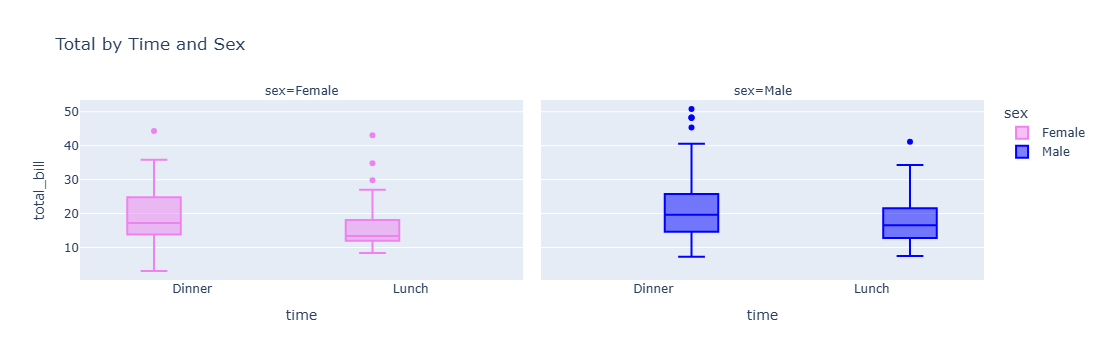

In [ ]:


# Cargar el conjunto de datos 'tips'
df = px.data.tips()

# Crear el gráfico de caja con facetas
fig = px.box(df, x="time", y="total_bill", title="Total by Time and Sex",
             facet_col="sex", color="sex", color_discrete_map={"Male": "blue", "Female": "violet"})

# Mostrar el gráfico
fig.show()

**Consideremos ahora tres factores**

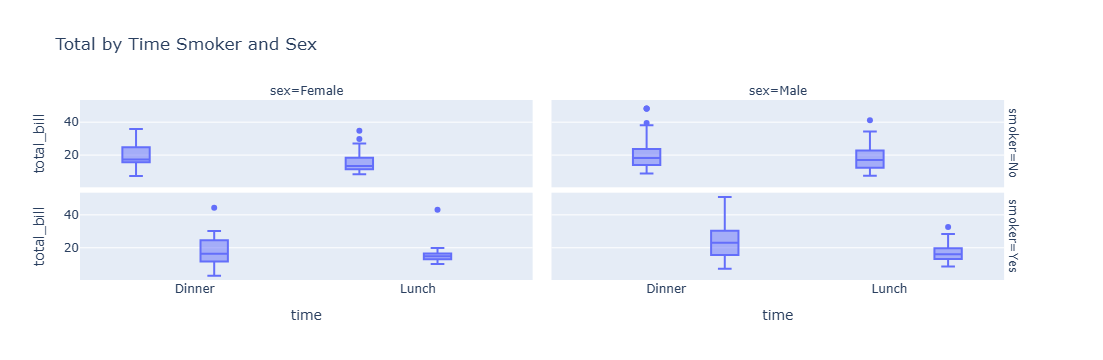

In [ ]:
# Cargar el conjunto de datos 'tips'
df = px.data.tips()

# Crear el gráfico de caja con facetas
fig = px.box(df, x="time", y="total_bill", title="Total by Time Smoker and Sex",
    facet_col="sex", facet_row="smoker")

# Mostrar el gráfico
fig.show()

**Cambiamos los colores de los boxplots**

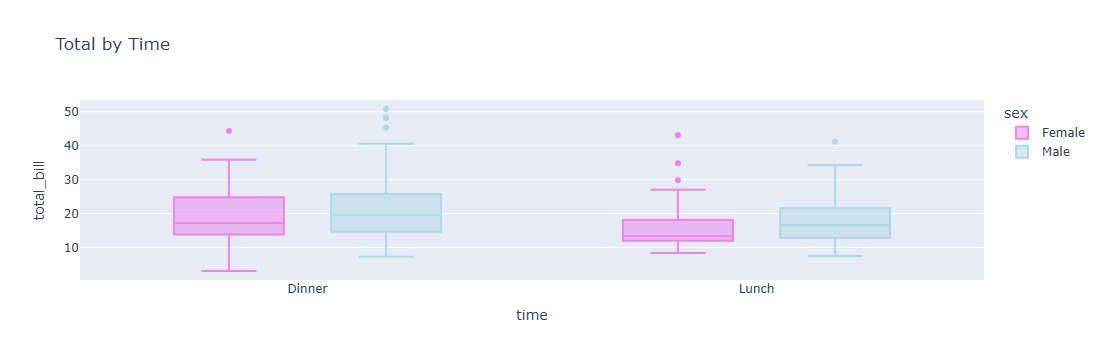

In [ ]:
import plotly.express as px

# Cargar el conjunto de datos 'tips'
df = px.data.tips()

# Crear el gráfico de caja con colores personalizados
fig = px.box(df, x="time", y="total_bill", title="Total by Time",
             color="sex",  # Cambiar el color según el género
             color_discrete_map={"Male": "lightblue", "Female": "violet"})  # Mapear los colores para cada categoría

# Mostrar el gráfico
fig.show()

**Cambiamos el color de fondo de la gráfica**

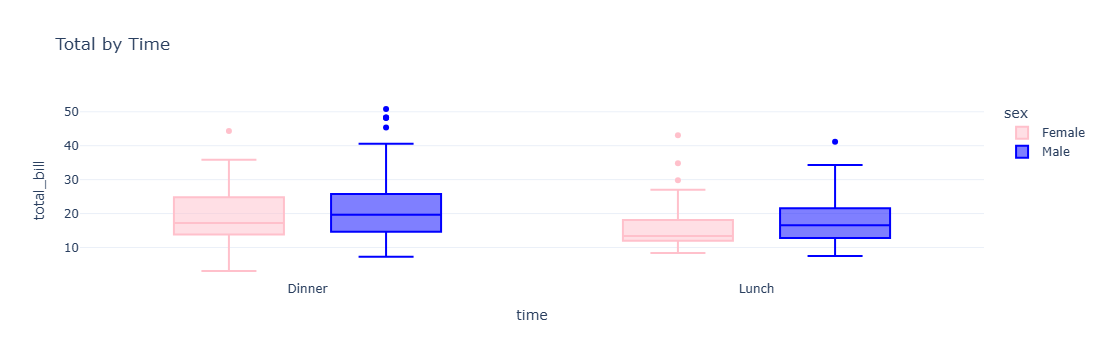

In [ ]:
import plotly.express as px

# Cargar el conjunto de datos 'tips'
df = px.data.tips()

# Crear el gráfico de caja con el template "plotly_dark"
fig = px.box(df, x="time", y="total_bill", title="Total by Time",
             color="sex",  # Cambiar el color según el género
             color_discrete_map={"Male": "blue", "Female": "pink"},  # Mapear los colores para cada categoría
             template="plotly_white")  # Aplicar el template "plotly_dark" para cambiar el color de fondo

# Mostrar el gráfico
fig.show()

**Pueden probar otros templates: plotly_dark, seaborn, ggplot2 o simple_white**

**Boxplots combinados con jitter plots**

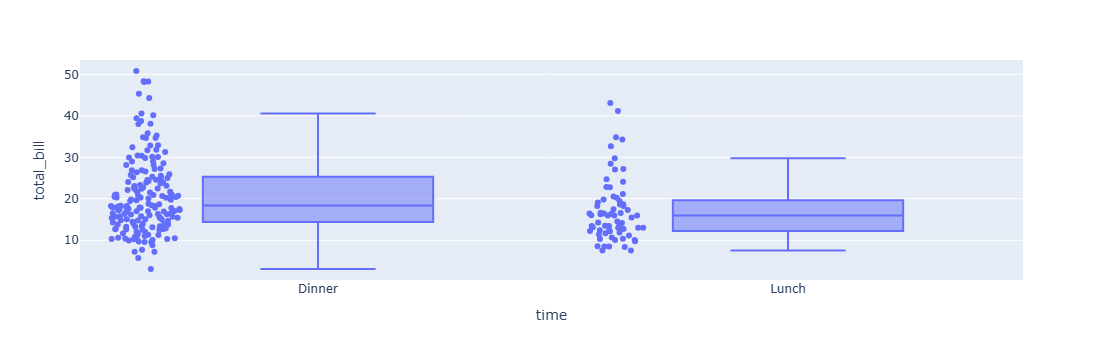

In [ ]:
import plotly.express as px
df = px.data.tips()
fig = px.box(df, x="time", y="total_bill", points="all")
fig.show()

**Considerando ahora dos variables categóricas pero en un mismo panel**

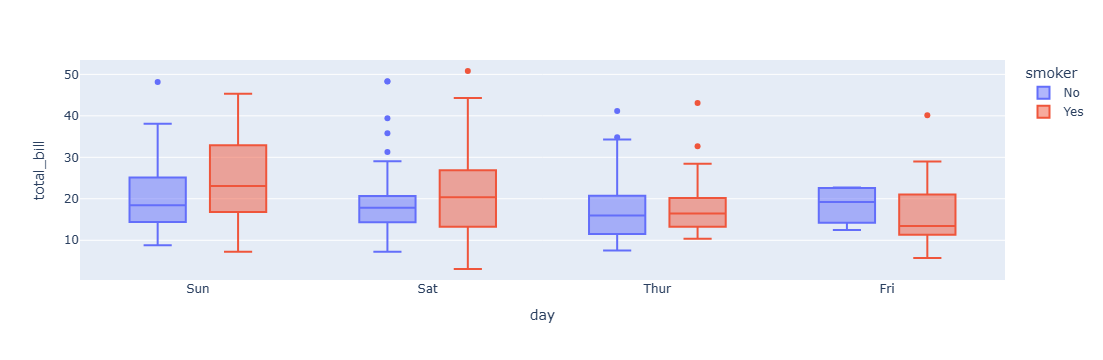

In [ ]:
import plotly.express as px

df = px.data.tips()

fig = px.box(df, x="day", y="total_bill", color="smoker")
fig.update_traces(quartilemethod="exclusive") 
fig.show()

**Boxplots con cintura**

Permiten visualmente apreciar los resultados del test de la mediana (Wilcoxon).

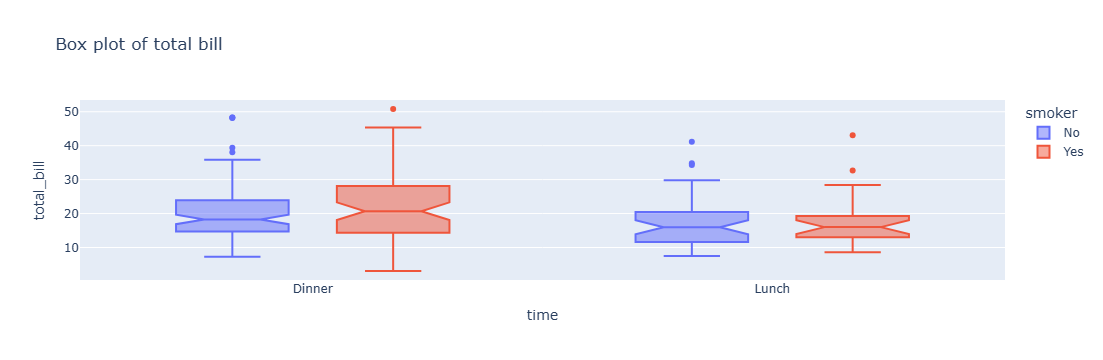

In [ ]:
import plotly.express as px
df = px.data.tips()
fig = px.box(df, x="time", y="total_bill", color="smoker",
             notched=True, # used notched shape
             title="Box plot of total bill",
             hover_data=["day"] # add day column to hover data
            )
fig.show()

**Boxplots horizontales**

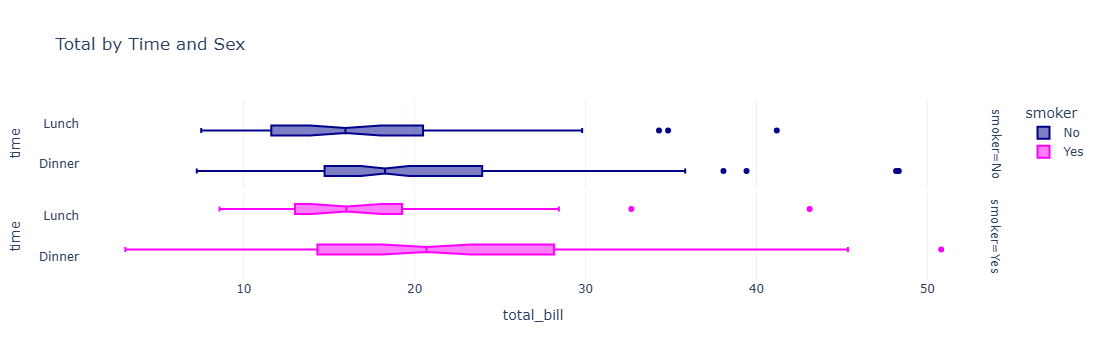

In [ ]:
import plotly.express as px

# Cargar el conjunto de datos 'tips'
df = px.data.tips()

# Crear el gráfico de caja con facetas y hacerlos horizontales
fig = px.box(df, y="time", x="total_bill", title="Total by Time and Sex",notched=True, template="plotly_white",
             facet_row="smoker", color="smoker", color_discrete_map={"No": "darkblue", "Yes": "magenta"})

# Mostrar el gráfico
fig.show()

**Cambiando los colores, ahora con paletas**

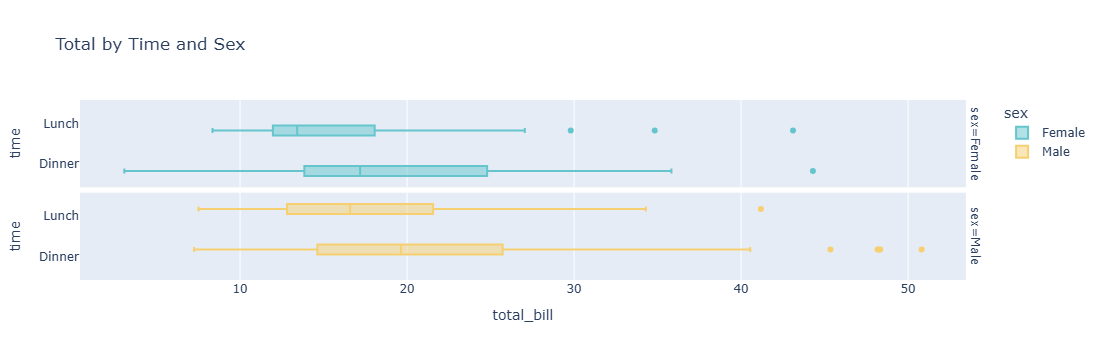

In [ ]:
import plotly.express as px

# Cargar el conjunto de datos 'tips'
df = px.data.tips()

# Crear el gráfico de caja con facetas y hacerlos horizontales
fig = px.box(df, y="time", x="total_bill", title="Total by Time and Sex",
             facet_row="sex", color="sex",
             color_discrete_sequence=px.colors.qualitative.Pastel)  # Usar la paleta "Pastel"

# Mostrar el gráfico
fig.show()

## Algunas paletas de colores disponibles

Cualitativas (discretas):

    px.colors.qualitative.Alphabet: Paleta con colores alfabéticos.
    px.colors.qualitative.D3: Paleta de colores inspirada en D3.js.
    px.colors.qualitative.G10: Paleta de colores de 10 colores distintos.
    px.colors.qualitative.Plotly: Paleta de colores de Plotly.
    px.colors.qualitative.Prism: Paleta de colores en tonos de arcoíris.
    px.colors.qualitative.Safe: Paleta de colores seguros para presentaciones.
    px.colors.qualitative.T10: Paleta de colores de 10 colores predefinidos.

Secuenciales (continuas):

    px.colors.sequential.Blues: Paleta de azules.
    px.colors.sequential.Reds: Paleta de rojos.
    px.colors.sequential.Greens: Paleta de verdes.
    px.colors.sequential.Purples: Paleta de púrpuras.
    px.colors.sequential.Oranges: Paleta de naranjas.
    px.colors.sequential.YlOrRd: Paleta de amarillos y naranjas.
    px.colors.sequential.Viridis: Paleta de colores perceptualmente uniformes.



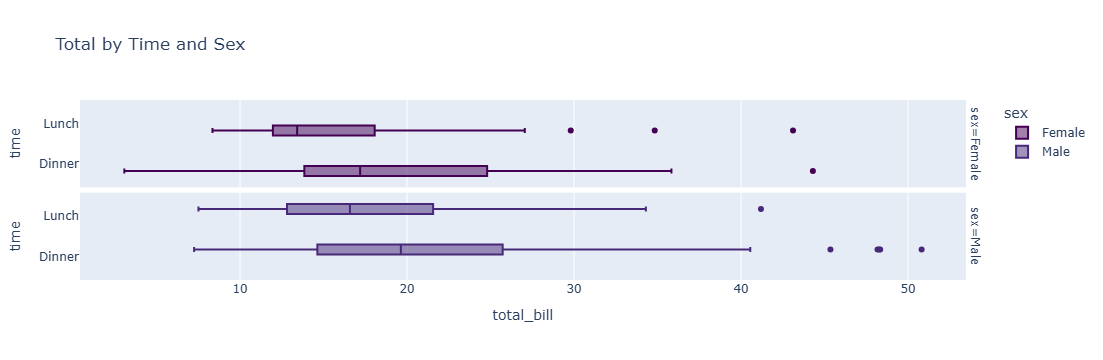

In [ ]:
import plotly.express as px

# Cargar el conjunto de datos 'tips'
df = px.data.tips()

# Crear el gráfico de caja con facetas y hacerlos horizontales
fig = px.box(df, y="time", x="total_bill", title="Total by Time and Sex",
             facet_row="sex", color="sex",
             color_discrete_sequence=px.colors.sequential.Viridis)  # Usar la paleta "Pastel"

# Mostrar el gráfico
fig.show()

## <font color="darkmagenta">**Gráficos de violín**</font> 


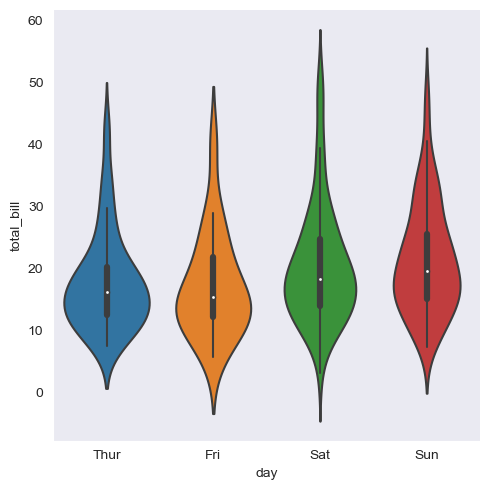

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# Desactivar todas las advertencias de futuro
warnings.simplefilter(action='ignore', category=FutureWarning)

# Cargar el conjunto de datos "tips" de seaborn
tips = sns.load_dataset("tips")

# Establecer el estilo de fondo (en este caso, el estilo "dark")
sns.set_style("dark")  # Puedes cambiar el estilo aquí

# Crear el gráfico de violín utilizando seaborn
# Crear el gráfico de violín utilizando seaborn

sns.catplot(x="day", y="total_bill", data=tips, kind="violin", dodge=True, observed=True)

# Mostrar el gráfico
plt.show()

**Podemos considerar un factor y subdividir en dos violines**

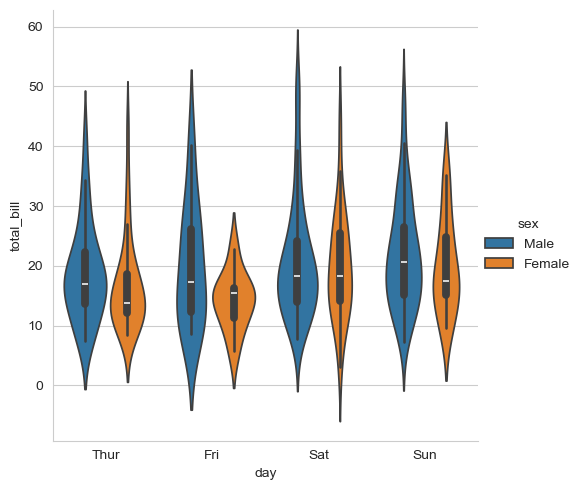

In [ ]:
import seaborn as sns

# Cargar el conjunto de datos 'tips'
tips = sns.load_dataset("tips")

# Establecer el estilo de fondo
sns.set_style("whitegrid")  # Puedes cambiar el estilo aquí

# Crear el gráfico de violín particionado por sexo
sns.catplot(x="day", y="total_bill", hue="sex",  data=tips, kind="violin")

# Mostrar el gráfico
plt.show()

**Podemos subdividir el mismo violín, izquierda y derecha por el factor**

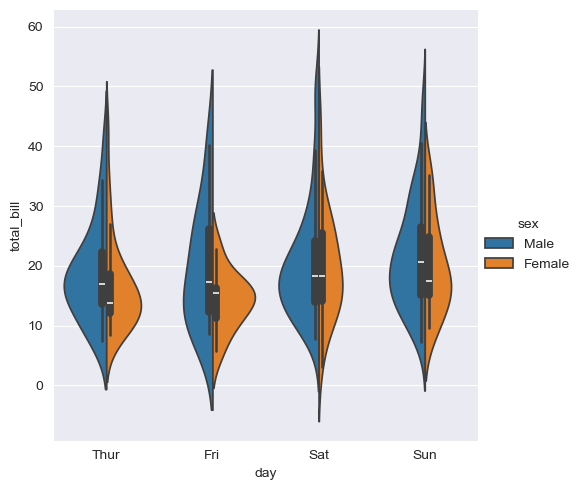

In [ ]:
import seaborn as sns

# Cargar el conjunto de datos 'tips'
tips = sns.load_dataset("tips")

# Establecer el estilo de fondo
sns.set_style( "darkgrid")  # Puedes cambiar el estilo aquí

# Crear el gráfico de violín con mitades divididas y particionado por sexo
sns.catplot(x="day", y="total_bill", hue="sex", data=tips, kind="violin", split=True)

# Mostrar el gráfico
plt.show()

El conjunto de datos **"diamonds"** es un conjunto de datos muy comúnmente utilizado en análisis de datos y aprendizaje automático. Contiene información sobre los precios y características de más de 53,000 diamantes.

Las variables en el conjunto de datos "diamonds" son las siguientes:

   **carat**: El peso del diamante, medido en quilates.
   
   **cut**: La calidad del corte del diamante, con valores que van desde "Fair" (regular) hasta "Ideal" (ideal).
   
   **color**: La claridad del color del diamante, con valores de "D" (mejor) a "J" (peor).
   
   **clarity**: La claridad del diamante, con valores que van desde "I1" (más bajo) hasta "IF" (más alto).
   
   **depth**: La profundidad total del diamante, como un porcentaje de su diámetro medio.
   
   **table**: El ancho del extremo superior del diamante en relación con su punto más ancho.
   
   **price**: El precio del diamante en dólares estadounidenses.
   
   **x**: La longitud en mm.
   
   **y**: La anchura en mm.
   
   **z**: La profundidad en mm.

In [ ]:
# importing seaborn library
import seaborn as sns
 
# importing dataset from the library
diam = sns.load_dataset('diamonds')
 
# printing the dataset
diam

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


## <font color="darkmagenta">**Histogramas y Curvas de Densidad**</font> 

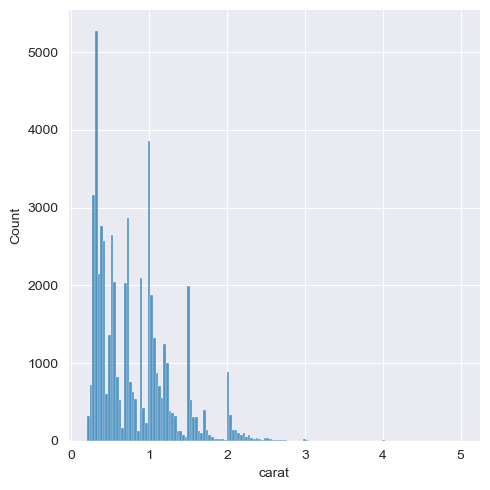

In [ ]:

# importamos las bibliotecas necesarias
import seaborn as sns
import matplotlib.pyplot as plt
 
# importamos la base de datos
diam = sns.load_dataset('diamonds')
 
# Trazar el histograma para 'carat' utilizando displot()
sns.displot(diam.carat, kde=False)

 
# visualizamos el gráfico
plt.show()

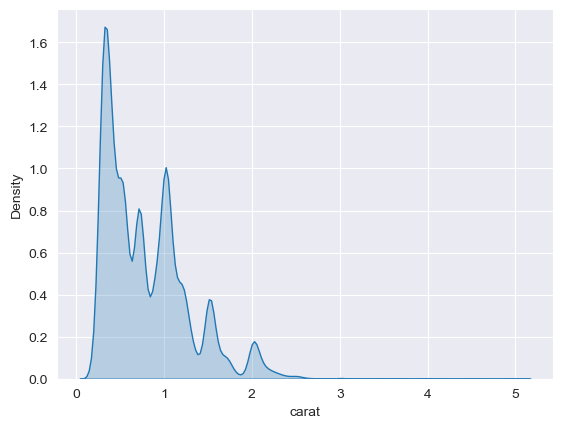

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el conjunto de datos 'diamonds'
diam = sns.load_dataset('diamonds')

# Trazar el gráfico de densidad para 'carat' utilizando kdeplot()
sns.kdeplot(data=diam.carat, fill=True)

# Mostrar el gráfico
plt.show()

**Varios gráficos de dispersión superpuestos**

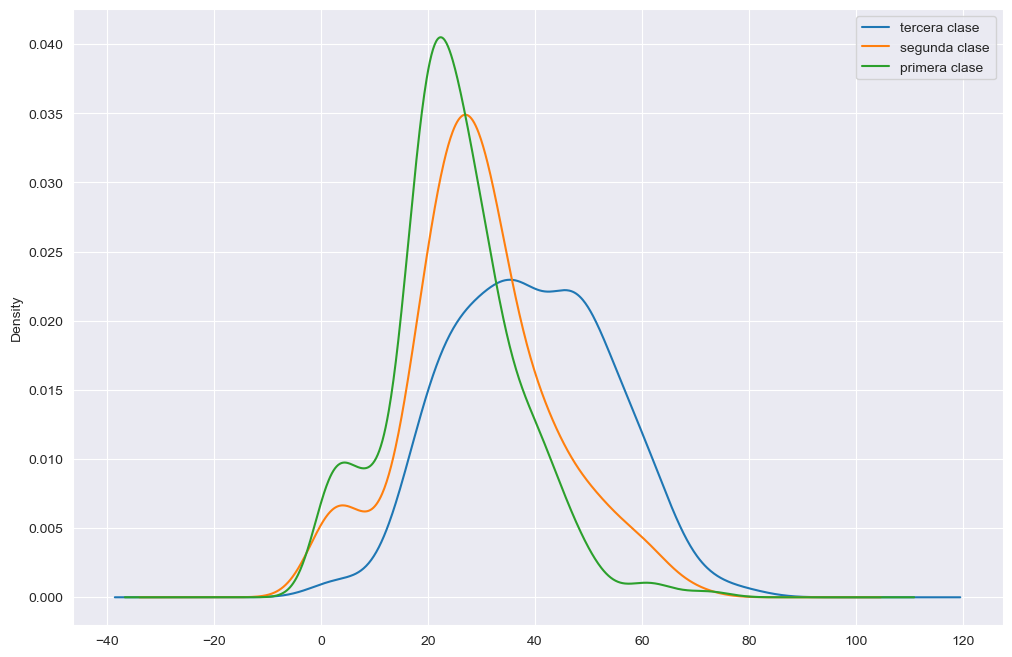

In [ ]:
fig = plt.figure(figsize=(12,8))
for t_class in [1,2,3]:
    titanic.age[titanic.pclass == t_class].plot(kind="kde")
    
plt.legend({"primera clase", "segunda clase", "tercera clase"})
plt.show()

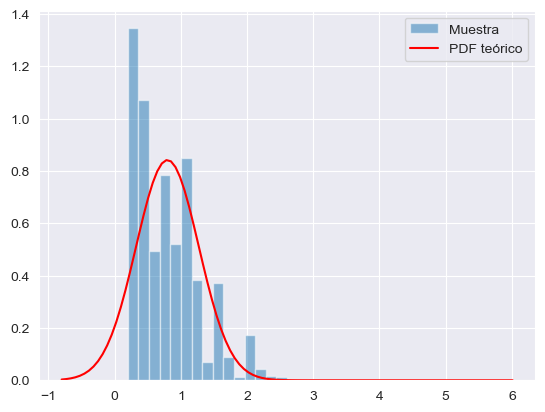

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Crear la distribución normal
dist = norm(loc=np.mean(diam.carat), scale=np.std(diam.carat))

# Trazar el histograma de la muestra
plt.hist(diam.carat, label="Muestra", bins=30, alpha=0.5, density=True)

# Trazar la función de densidad de probabilidad (PDF) teórica
x = np.linspace(diam.carat.min() - 1, diam.carat.max() + 1, 100)
plt.plot(x, dist.pdf(x), "r-", label="PDF teórico")

# Mostrar la leyenda
plt.legend()

# Mostrar el gráfico
plt.show()

# **Ejercicio 25:**
* Importar la base IMCinfantil  guardarla en el objeto imc
* Seleccionar la variable talla y realizar un gráfico de caja
* Seleccionar la variable peso y realizar un boxplot con cintura particionado por la variable CatPeso
* Con la variable IMC realizar un gráfico de violín donde se particione por la variable CatPeso
* Realizar algún comentario de los gráficos



## <font color="darkmagenta">Heatmaps</font>

In [ ]:
galletitas=pd.read_excel('C:/Users/Debora/Dropbox/AustralPosgrado/CursoPythonPampa/Clase3/galletitas.xlsx' )
galle=galletitas.iloc[:, 1:6]
galle



,Calorias,Carbohidratos,Proteinas,Grasas,Sodio
0,439,65.0,11.0,15,574.00
1,466,57.0,10.0,22,828.00
2,445,69.0,11.0,14,12.00
3,478,67.0,5.6,21,363.00
4,464,70.0,6.3,18,263.00
5,463,66.0,7.1,19,136.00
6,438,69.0,11.0,13,431.00
7,418,69.0,6.3,13,201.00
8,423,70.0,6.8,13,241.00
9,444,73.0,9.0,13,375.00


               Calorias  Carbohidratos  Proteinas    Grasas     Sodio
Calorias       1.000000      -0.214762   0.004858  0.800272  0.444225
Carbohidratos -0.214762       1.000000  -0.177187 -0.694484 -0.467082
Proteinas      0.004858      -0.177187   1.000000 -0.152458  0.522288
Grasas         0.800272      -0.694484  -0.152458  1.000000  0.433265
Sodio          0.444225      -0.467082   0.522288  0.433265  1.000000


<Axes: >

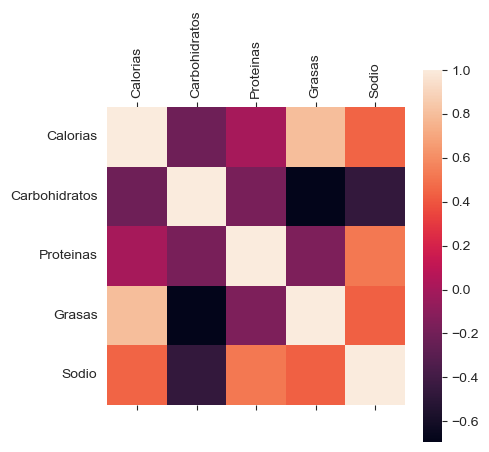

In [ ]:
corr=galle.corr()
print(galle.corr())
plt.matshow(galle.corr())

sns.heatmap(corr, 
      xticklabels=corr.columns.values, 
      yticklabels=corr.columns.values) 

## <font color="darkmagenta">Diagrama de Dispersión o Scatter Plot</font>

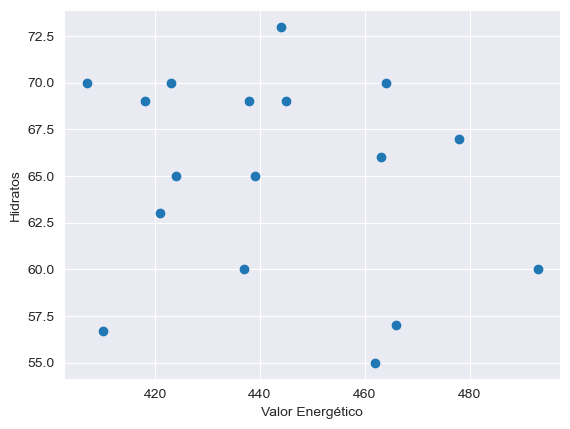

In [ ]:
calorias = galletitas['Calorias']
carbohidratos = galletitas['Carbohidratos']

# Graficar el scatter plot
plt.scatter(calorias, carbohidratos)

# Etiquetas de los ejes
plt.xlabel('Valor Energético')
plt.ylabel('Hidratos')

# Activar la cuadrícula
plt.grid(True)

# Mostrar el gráfico
plt.show()

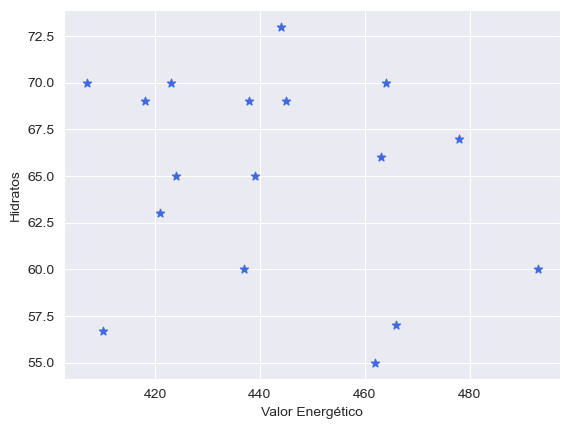

In [ ]:
 # Graficar el scatter plot
plt.scatter(calorias, carbohidratos, marker = "*",color="RoyalBlue")

# Etiquetas de los ejes
plt.xlabel('Valor Energético')
plt.ylabel('Hidratos')

# Activar la cuadrícula
plt.grid(True)

# Mostrar el gráfico
plt.show()
   

**Señalamos categorias distintas con colores distintos**

In [ ]:
tipo=galletitas['Tipo']
tipo

0      dulce
1      dulce
2      dulce
3     salada
4     salada
5     salada
6      dulce
7     salada
8     salada
9     salada
10    salada
11    salada
12    salada
13    salada
14     dulce
15     dulce
16     dulce
Name: Tipo, dtype: object

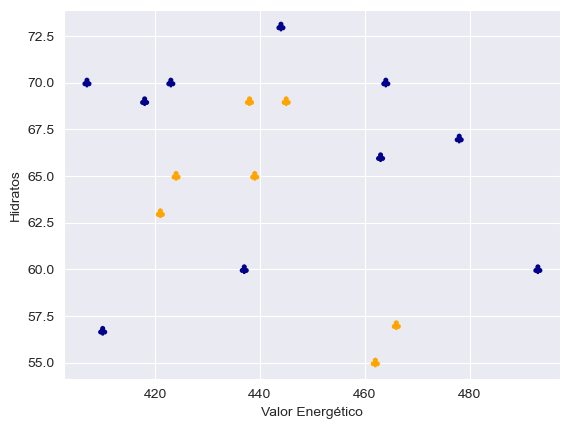

In [ ]:


color = np.where(tipo =="dulce", "orange", "darkblue")
color
# Graficar el scatter plot
plt.scatter(calorias, carbohidratos, marker = "$\clubsuit$",color=color)

# Etiquetas de los ejes
plt.xlabel('Valor Energético')
plt.ylabel('Hidratos')

# Activar la cuadrícula
plt.grid(True)

# Mostrar el gráfico
plt.show()

   




**Podemos cambiar el tamaño de los símbolos**

<>:4: SyntaxWarning:

invalid escape sequence '\c'

<>:4: SyntaxWarning:

invalid escape sequence '\c'

C:\Users\Debora\AppData\Local\Temp\ipykernel_24000\3609476871.py:4: SyntaxWarning:

invalid escape sequence '\c'



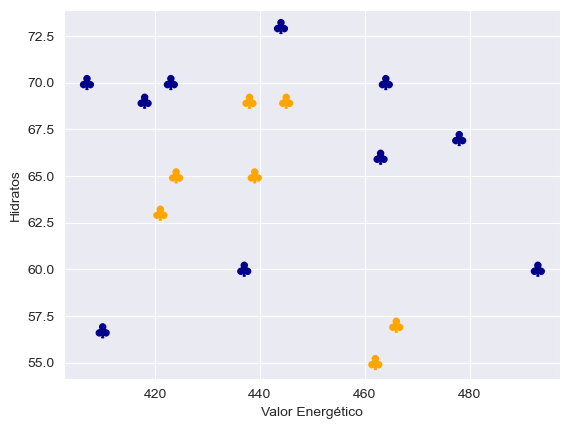

In [ ]:
color = np.where(tipo =="dulce", "orange", "darkblue")
color
# Graficar el scatter plot
plt.scatter(calorias, carbohidratos, marker = "$\clubsuit$",color=color,s=100)

# Etiquetas de los ejes
plt.xlabel('Valor Energético')
plt.ylabel('Hidratos')

# Activar la cuadrícula
plt.grid(True)

# Mostrar el gráfico
plt.show()




## <font color="darkmagenta">Gráfico de burbujas</font>

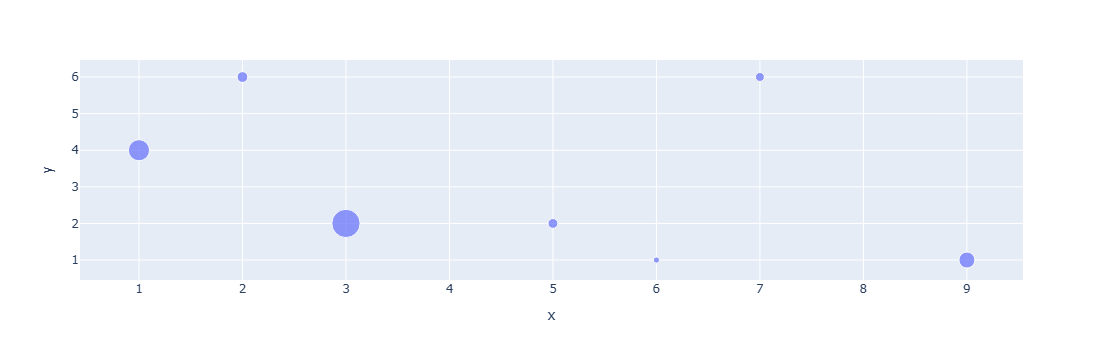

In [ ]:
import plotly.express as px

fig = px.scatter(x = [5, 7, 3, 6, 1, 9, 2],
                 y = [2, 6, 2, 1, 4, 1, 6],
                 size = [30, 25, 250, 12, 140, 80, 36])

fig.show()

**Además del tamaño de la burbuja podemos administrar el color de las mismas**

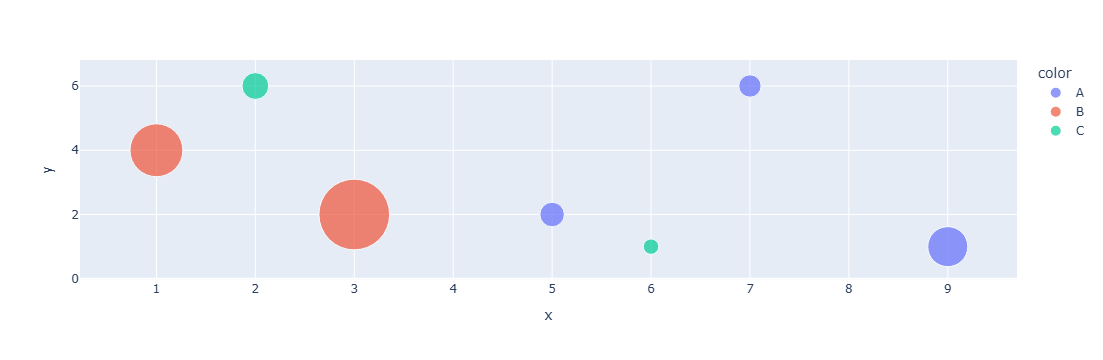

In [ ]:
import plotly.express as px

fig = px.scatter(x = [5, 7, 3, 6, 1, 9, 2],
                 y = [2, 6, 2, 1, 4, 1, 6],
                 size = [30, 25, 250, 12, 140, 80, 36],
                 size_max = 50,
                 color = ['A', 'A', 'B', 'C', 'B', 'A', 'C'])

fig.show()

## Scatter plot 3D

Text(0.5, 0.92, 'Gráfico de dispersión 3D')

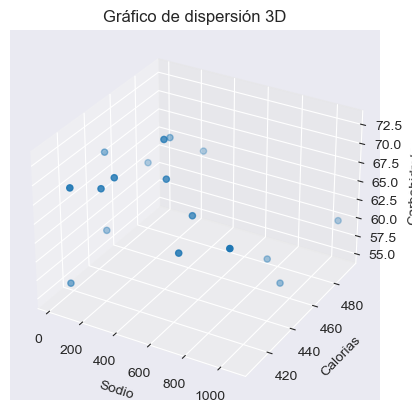

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x=galle['Sodio']
y=galle['Calorias']
z=galle['Carbohidratos']

fig = plt.figure()
ax = fig.add_subplot(projection = '3d')

# Gráfico de dispersión 3D
ax.scatter(x, y, z)

# Etiquetas de los ejes
ax.set_xlabel('Sodio')
ax.set_ylabel('Calorias')
ax.set_zlabel('Carbohidratos')

# Título
plt.title("Gráfico de dispersión 3D")

# plt.show()